<a href="https://colab.research.google.com/github/GiacomoSilvello/UAV-damage-assessment/blob/main/Analisi_Modello_Segmentazione.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================================
# SEZIONE 0 — SETUP: librerie, percorsi, costanti e funzioni condivise
# Da eseguire SEMPRE per prima. Tutte le sezioni successive usano queste
# variabili. Nessuna sezione ricarica il Drive o ridefinisce i percorsi.
# ============================================================================
from google.colab import drive
drive.mount('/content/drive')

import os, re, glob, random
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
from scipy import stats

pd.set_option('display.width', 200)

# ---------------------------------------------------------------- percorsi
DRIVE_BASE = '/content/drive/MyDrive/RescueNet_Output'
REGIME     = 'res713'

ORIG_DIR = f'{DRIVE_BASE}/test_originali'      # immagini originali del test set
GT_DIR   = f'{DRIVE_BASE}/colormasks'          # ground truth colorate (_lab.png)

# cartella maschere del checkpoint più allenato
_cart = glob.glob(f'{DRIVE_BASE}/predictions_{REGIME}_ep*')
if not _cart:
    raise SystemExit(f"Nessuna cartella predictions_{REGIME}_ep* in {DRIVE_BASE}")
def _nep(p):
    m = re.search(r'_ep(\d+)$', p); return int(m.group(1)) if m else -1
PRED_DIR = max(_cart, key=_nep)
EP = EPOCHE = _nep(PRED_DIR)
EPOCHE_DISP = sorted(_nep(c) for c in _cart)
print(f"Regime: {REGIME}  |  checkpoint più allenato: {EP} epoche")
print(f"Epoche con maschere disponibili: {EPOCHE_DISP}")

# ---------------------------------------------------------------- classi
CLASSI = [('Sfondo',(0,0,0)), ('Acqua',(61,230,250)), ('Edificio-NoDanno',(180,120,120)),
          ('Edificio-DannoMin',(235,255,7)), ('Edificio-DannoGrave',(255,184,6)),
          ('Edificio-Distruzione',(255,0,0)), ('Veicolo',(255,0,245)),
          ('Strada',(140,140,140)), ('Strada-Bloccata',(160,150,20)),
          ('Albero',(4,250,7)), ('Piscina',(255,235,0))]
NOMI = [n for n,_ in CLASSI]
NC   = len(CLASSI)
COLORI = {c:n for n,c in CLASSI}          # colore -> nome (per legende)

# classi di edificio, in ordine di gravità
RN      = {(180,120,120):'no', (235,255,7):'medio', (255,184,6):'grave', (255,0,0):'distr'}
ORDINE  = ['no','medio','grave','distr']

# ---------------------------------------------------------------- funzioni condivise
def to_idx(arr):
    out = np.full(arr.shape[:2], 255, np.uint8)
    for i, classe_info in enumerate(CLASSI):
        # classe_info[1] estrae il colore (r, g, b), indipendentemente
        # da quanti elementi compongono la tupla in CLASSI
        c = classe_info[1]
        out[np.all(arr == np.array(c), axis=-1)] = i
    return out

def conta_edifici(arr):
    """Pixel per ciascuna classe di edificio in una maschera RGB."""
    out = {k:0 for k in ORDINE}
    cols, cnts = np.unique(arr.reshape(-1,3), axis=0, return_counts=True)
    for c, n in zip(cols, cnts):
        t = tuple(int(x) for x in c)
        if t in RN: out[RN[t]] += int(n)
    return out

def apri(cartella, nome, exts=('.png','.PNG','.jpg','.JPG')):
    """Apre la prima immagine esistente fra le estensioni indicate."""
    for e in exts:
        p = os.path.join(cartella, nome + e)
        if os.path.exists(p): return Image.open(p)
    return None

def maschere_di(cartella):
    return sorted(f for f in os.listdir(cartella) if f.endswith('.png'))

# ---------------------------------------------------------------- CSV per-immagine
modelli, metriche = {}, {}
for f in sorted(glob.glob(f'{DRIVE_BASE}/risultati_{REGIME}_ep*.csv')):
    modelli[int(re.search(rf'risultati_{REGIME}_ep(\d+)', f).group(1))] = pd.read_csv(f)
for f in sorted(glob.glob(f'{DRIVE_BASE}/metriche_{REGIME}_ep*.csv')):
    d = pd.read_csv(f)
    metriche[int(re.search(rf'metriche_{REGIME}_ep(\d+)', f).group(1))] = \
        dict(zip(d['Metrica'], pd.to_numeric(d['Valore'], errors='coerce')))

if modelli:
    EPOCHE = max(modelli.keys())
    df = modelli[EPOCHE]
    print(f"\nCSV per-immagine: epoche {sorted(modelli.keys())}  ->  analizzo {EPOCHE} ep ({len(df)} immagini)")
else:
    df = None
    print("\nATTENZIONE: nessun risultati_*.csv trovato.")
print(f"CSV metriche ufficiali: epoche {sorted(metriche.keys())}")


Mounted at /content/drive
Regime: res713  |  checkpoint più allenato: 100 epoche
Epoche con maschere disponibili: [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]

CSV per-immagine: epoche [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]  ->  analizzo 100 ep (450 immagini)
CSV metriche ufficiali: epoche [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]


In [ ]:
# ============================================================================
# SEZIONE 1 — CARATTERIZZAZIONE DEL DATASET DI TEST
# Composizione media delle scene, presenza delle classi, statistiche
# descrittive su danno agli edifici e qualità della predizione.
# ============================================================================
import os
import re
import pandas as pd

# ANALISI ESTESA del modello selezionato
pd.set_option('display.width', 200)

col_perc = [c for c in df.columns if c.startswith('perc_')]
composizione = df[col_perc].mean().sort_values(ascending=False)
print("--- Composizione media delle scene (% pixel per classe) ---")
for nome, val in composizione.items():
    if val > 0.001:
        print(f"  {nome.replace('perc_',''):32s} {val:7.3f}%")
print(f"\n  Classi mai predette: "
      f"{[c.replace('perc_','') for c in col_perc if df[c].max() == 0]}")

print("\n--- Presenza delle classi (su quante immagini compaiono) ---")
for c in col_perc:
    n = (df[c] > 0).sum()
    if n > 0:
        print(f"  {c.replace('perc_',''):32s} {n:4d}/{len(df)}  ({n/len(df)*100:.1f}%)")

edif  = df['Perc_Edifici_Totale']
print(f"  Immagini con edifici rilevati: {(edif > 0).sum()}/{len(df)}")
print(f"  Superficie media occupata da edifici: {edif.mean():.2f}%")


# ============================================================================
# LETTURA DELLE METRICHE GLOBALI UFFICIALI DAL FILE .TXT
# ============================================================================
txt_path = f"{DRIVE_BASE}/metriche_{REGIME}_ep{EPOCHE}.txt"
global_miou = None
class_ious = {}

if os.path.exists(txt_path):
    parsing_classes = False
    with open(txt_path, 'r') as f:
        for line in f:
            # Identifica la riga con la metrica globale
            if "Mean IoU:" in line:
                m = re.search(r'Mean IoU:\s*([0-9.]+)', line)
                if m: global_miou = float(m.group(1))
                parsing_classes = True
                continue

            # Legge i valori di IoU per le singole classi
            if parsing_classes:
                if "A batch" in line or "torch.Size" in line:
                    parsing_classes = False
                    continue
                if ":" in line:
                    parts = line.split(":")
                    if len(parts) == 2:
                        c_name = parts[0].strip()
                        c_val = parts[1].strip()
                        if c_val != 'nan': # Ignoro lo sfondo (unlabeled)
                            try:
                                class_ious[c_name] = float(c_val)
                            except ValueError:
                                pass

    print("\n--- METRICHE GLOBALI UFFICIALI (da test.py) ---")
    if global_miou is not None:
        print(f"  Mean IoU Globale (escluso sfondo): {global_miou:.4f}")
    print("  IoU per singola classe:")
    for c_name, c_val in class_ious.items():
        print(f"    - {c_name:28s} {c_val:.4f}")
else:
    print(f"\n[Attenzione] File {txt_path} non trovato. Impossibile caricare metriche globali.")


# ============================================================================
# ANALISI QUALITATIVA E RICERCA EDGE CASES (tramite mIoU per-immagine)
# ============================================================================
if 'mIoU_immagine' in df.columns:
    iou = pd.to_numeric(df['mIoU_immagine'], errors='coerce')
    acc = pd.to_numeric(df['Accuracy_immagine'], errors='coerce')

    print("\n--- Analisi per-immagine (Ricerca Edge Cases per la tesi) ---")
    print("  Nota: questi quartili illustrano la varianza delle performance sulle singole")
    print("  immagini e differiscono dal mIoU Globale calcolato sull'intero dataset.")
    print(f"  Quartili mIoU: Q1={iou.quantile(.25):.4f}  "
          f"Q2 (Mediana)={iou.quantile(.50):.4f}  Q3={iou.quantile(.75):.4f}")

    print("\n  Migliori 5 immagini (Casi ideali):")
    print(df.assign(_i=iou).nlargest(5,'_i')[['ID_Immagine','mIoU_immagine','Accuracy_immagine']].to_string(index=False))

    print("\n  Peggiori 5 immagini (Casi di fallimento del modello):")
    print(df.assign(_i=iou).nsmallest(5,'_i')[['ID_Immagine','mIoU_immagine','Accuracy_immagine']].to_string(index=False))

--- Composizione media delle scene (% pixel per classe) ---
  Background                        52.938%
  Tree                              25.640%
  Water                              7.088%
  Road-Clear                         6.699%
  Building-No-Damage                 3.052%
  Building-Minor-Damage              1.768%
  Building-Major-Damage              1.030%
  Building-Total-Destruction         0.836%
  Road-Blocked                       0.722%
  Vehicle                            0.193%
  Pool                               0.034%

  Classi mai predette: []

--- Presenza delle classi (su quante immagini compaiono) ---
  Background                        427/450  (94.9%)
  Water                             230/450  (51.1%)
  Building-No-Damage                262/450  (58.2%)
  Building-Minor-Damage             210/450  (46.7%)
  Building-Major-Damage             160/450  (35.6%)
  Building-Total-Destruction        106/450  (23.6%)
  Vehicle                           183/450  (40.

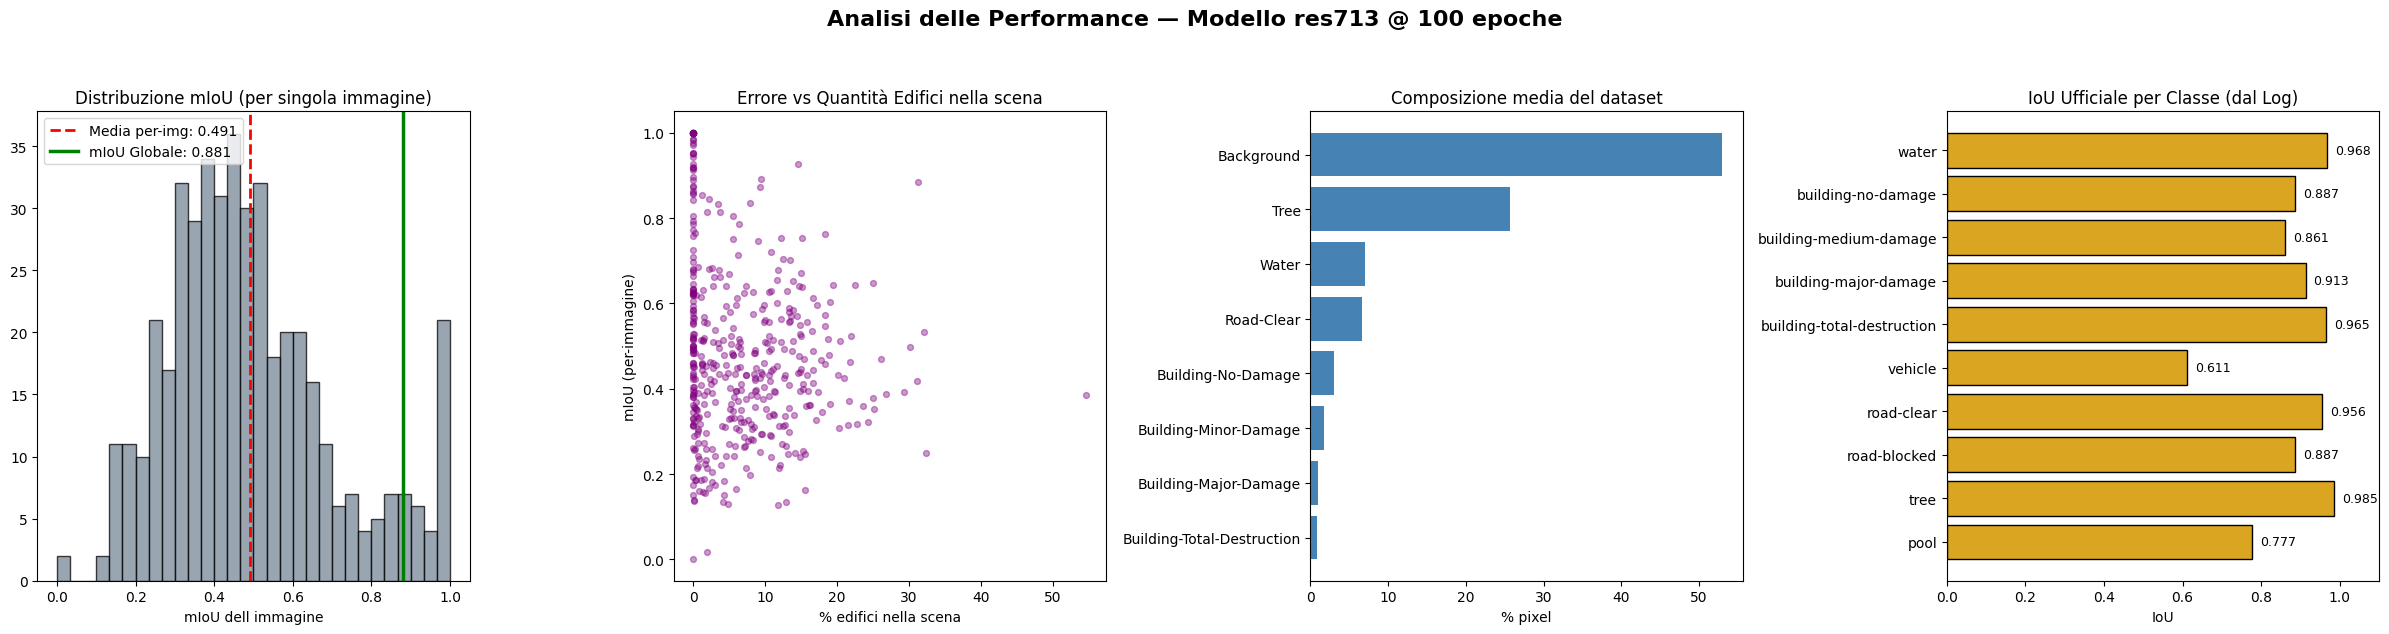

In [ ]:
# ============================================================================
# 1.1 · QUATTRO GRAFICI del modello selezionato
# ============================================================================
import matplotlib.pyplot as plt
import pandas as pd

fig, ax = plt.subplots(1, 4, figsize=(24, 6))

if 'mIoU_immagine' in df.columns:
    iou = pd.to_numeric(df['mIoU_immagine'], errors='coerce')

    # GRAFICO 1: Istogramma (mostro entrambe le medie per far capire la differenza)
    ax[0].hist(iou.dropna(), bins=30, edgecolor='black', alpha=.75, color='lightslategray')
    ax[0].axvline(iou.mean(), color='red', ls='--', lw=2, label=f'Media per-img: {iou.mean():.3f}')

    # Se la cella precedente ha estratto il mIoU globale dal .txt, lo traccio!
    if 'global_miou' in globals() and global_miou is not None:
        ax[0].axvline(global_miou, color='green', ls='-', lw=2.5, label=f'mIoU Globale: {global_miou:.3f}')

    ax[0].set_title('Distribuzione mIoU (per singola immagine)')
    ax[0].set_xlabel('mIoU dell immagine')
    ax[0].legend(loc='upper left')

    # GRAFICO 2: Scatter plot della qualità vs la presenza di edifici
    ax[1].scatter(df['Perc_Edifici_Totale'], iou, alpha=.4, s=18, color='purple')
    ax[1].set_title('Errore vs Quantità Edifici nella scena')
    ax[1].set_xlabel('% edifici nella scena')
    ax[1].set_ylabel('mIoU (per-immagine)')

# GRAFICO 3: Composizione media delle scene
top = composizione[composizione > 0.01].head(8)
ax[2].barh([n.replace('perc_','') for n in top.index][::-1], top.values[::-1], color='steelblue')
ax[2].set_title('Composizione media del dataset')
ax[2].set_xlabel('% pixel')

# GRAFICO 4: Le vere IoU Ufficiali per singola classe (Lette dal file .txt)
if 'class_ious' in globals() and class_ious:
    c_names = list(class_ious.keys())
    c_vals = list(class_ious.values())

    # Creo un bar plot orizzontale
    ax[3].barh(c_names[::-1], c_vals[::-1], color='goldenrod', edgecolor='black')

    # Aggiungo il numeretto di fianco ad ogni barra per chiarezza
    for i, v in enumerate(c_vals[::-1]):
        ax[3].text(v + 0.02, i, f'{v:.3f}', va='center', fontsize=9)

    ax[3].set_title('IoU Ufficiale per Classe (dal Log)')
    ax[3].set_xlabel('IoU')
    ax[3].set_xlim(0, 1.1)
else:
    ax[3].text(0.5, 0.5, 'Dati IoU per classe non trovati\n(Esegui prima la cella 1.1)',
               ha='center', va='center')

plt.suptitle(f'Analisi delle Performance — Modello {REGIME} @ {EPOCHE} epoche', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

Matrice di confusione (per riga) — res713 @ 100 epoche
  100/450...
  200/450...
  300/450...
  400/450...
Classi escluse (Sfondo + assenti nel test set): ['Sfondo', 'Piscina']


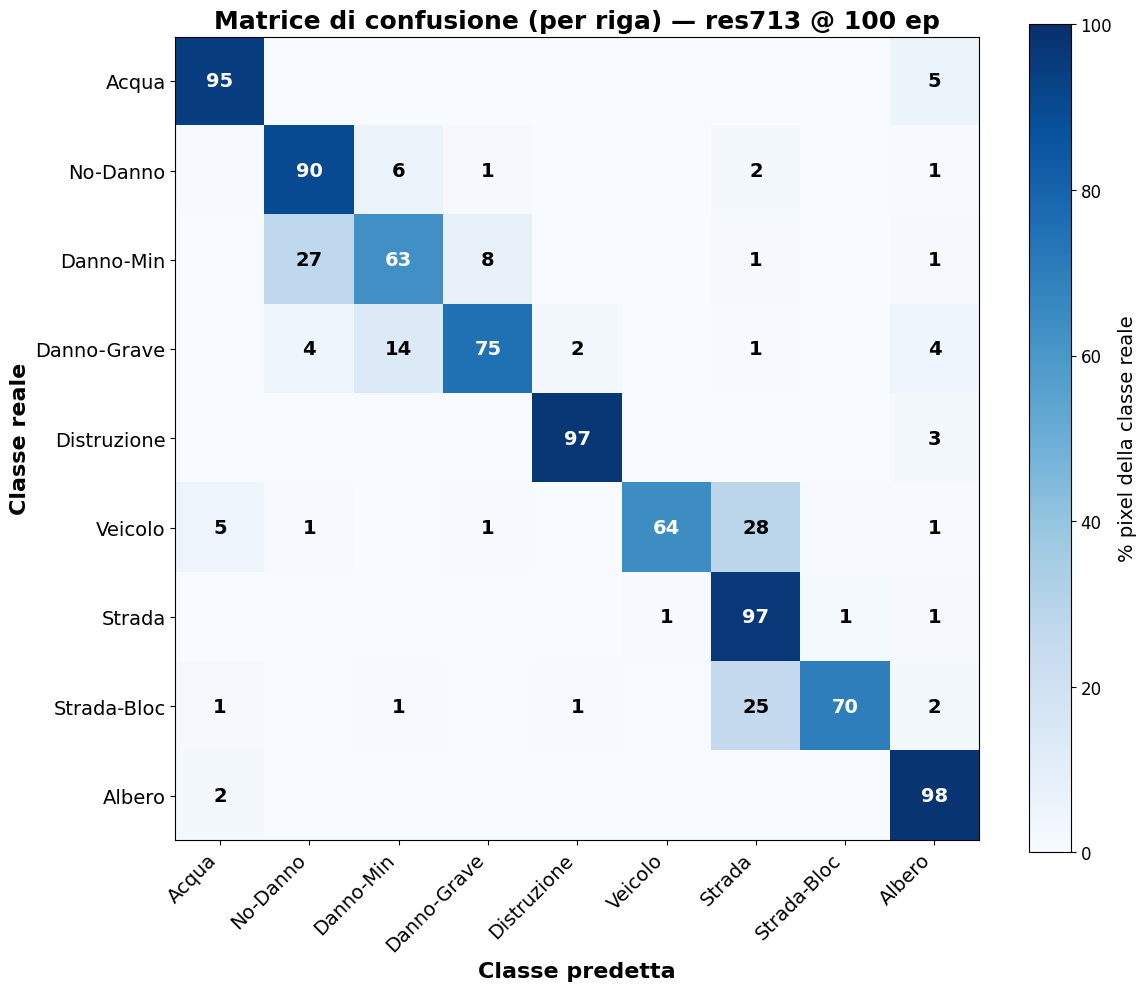

Somma per riga (interi mostrati): [100 100 100 100 100 100 100 100 100]


In [ ]:
# ============================================================================
# 2.1 · Matrice di confusione fra classi (% per RIGA, somma esatta 100)
# ============================================================================
import os, re, glob
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

cart = glob.glob(f'{DRIVE_BASE}/predictions_{REGIME}_ep*')
def n_ep(p):
    m=re.search(r'_ep(\d+)$',p); return int(m.group(1)) if m else -1
PRED_DIR = max(cart, key=n_ep); EP_CM = n_ep(PRED_DIR)
GT_DIR   = f'{DRIVE_BASE}/colormasks'
print(f"Matrice di confusione (per riga) — {REGIME} @ {EP_CM} epoche")

CLASSI = [('Sfondo',(0,0,0)),('Acqua',(61,230,250)),('No-Danno',(180,120,120)),
          ('Danno-Min',(235,255,7)),('Danno-Grave',(255,184,6)),
          ('Distruzione',(255,0,0)),('Veicolo',(255,0,245)),('Strada',(140,140,140)),
          ('Strada-Bloc',(160,150,20)),('Albero',(4,250,7)),('Piscina',(255,235,0))]
NOMI = [n for n,_ in CLASSI]; NC = len(CLASSI)

def to_idx(arr):
    out = np.full(arr.shape[:2], 255, np.uint8)
    for i,(_,c) in enumerate(CLASSI):
        out[np.all(arr==np.array(c),axis=-1)] = i
    return out

cm = np.zeros((NC, NC), dtype=np.int64)
maschere = sorted(f for f in os.listdir(PRED_DIR) if f.endswith('.png'))
for k,m in enumerate(maschere,1):
    base = m[:-4]
    gtp = os.path.join(GT_DIR, base+'_lab.png')
    if not os.path.exists(gtp): continue
    pred = to_idx(np.array(Image.open(os.path.join(PRED_DIR,m)).convert('RGB')))
    gt   = to_idx(np.array(Image.open(gtp).convert('RGB')))
    if gt.shape != pred.shape:
        gt = np.array(Image.fromarray(gt).resize((pred.shape[1], pred.shape[0]), Image.NEAREST))
    valid = (gt > 0) & (gt < NC) & (pred < NC)
    for t,pr in zip(gt[valid].ravel(), pred[valid].ravel()):
        cm[t,pr]+=1
    if k%100==0: print(f"  {k}/{len(maschere)}...")

presenti = [i for i in range(1, NC) if cm[i].sum() > 0]
escluse  = [NOMI[i] for i in range(NC) if i not in presenti]
print(f"Classi escluse (Sfondo + assenti nel test set): {escluse}")

cm_v   = cm[np.ix_(presenti, presenti)]
nomi_v = [NOMI[i] for i in presenti]
NCv    = len(presenti)

# --- normalizzazione per riga in percentuale (float) ---
cm_pct = cm_v / cm_v.sum(axis=1, keepdims=True).clip(min=1) * 100

# --- arrotondamento a intero con "largest remainder" per riga: somma esatta 100 ---
def arrotonda_a_100(vett):
    """Arrotonda un vettore di percentuali a interi mantenendo la somma originale (100)."""
    tot = int(round(vett.sum()))            # normalmente 100 (0 se riga vuota)
    if tot == 0:
        return np.zeros_like(vett, dtype=int)
    giu = np.floor(vett).astype(int)
    resto = int(tot - giu.sum())            # unità da ridistribuire
    if resto > 0:
        ordine = np.argsort(-(vett - giu))  # celle col resto decimale più alto
        for idx in ordine[:resto]:
            giu[idx] += 1
    elif resto < 0:
        ordine = np.argsort(vett - giu)
        for idx in ordine[:(-resto)]:
            giu[idx] -= 1
    return giu

cm_int = np.vstack([arrotonda_a_100(cm_pct[r]) for r in range(NCv)])

fig, ax = plt.subplots(figsize=(12,10))
im = ax.imshow(cm_pct, cmap='Blues', vmin=0, vmax=100)   # colore dal valore esatto
ax.set_xticks(range(NCv)); ax.set_xticklabels(nomi_v, rotation=45, ha='right', fontsize=14)
ax.set_yticks(range(NCv)); ax.set_yticklabels(nomi_v, fontsize=14)
ax.set_xlabel('Classe predetta', fontweight='bold', fontsize=16)
ax.set_ylabel('Classe reale', fontweight='bold', fontsize=16)
ax.set_title(f'Matrice di confusione (per riga) — {REGIME} @ {EP_CM} ep', fontweight='bold', fontsize=18)
for i in range(NCv):
    for j in range(NCv):
        v = cm_int[i,j]
        if v >= 1:
            ax.text(j,i,f'{v:d}',ha='center',va='center',
                    color='white' if cm_pct[i,j]>50 else 'black', fontsize=14, fontweight='bold')
cbar = plt.colorbar(im); cbar.set_label('% pixel della classe reale', fontsize=14)
cbar.ax.tick_params(labelsize=12)
ax.grid(False); plt.tight_layout(); plt.show()

print("Somma per riga (interi mostrati):", cm_int.sum(axis=1))

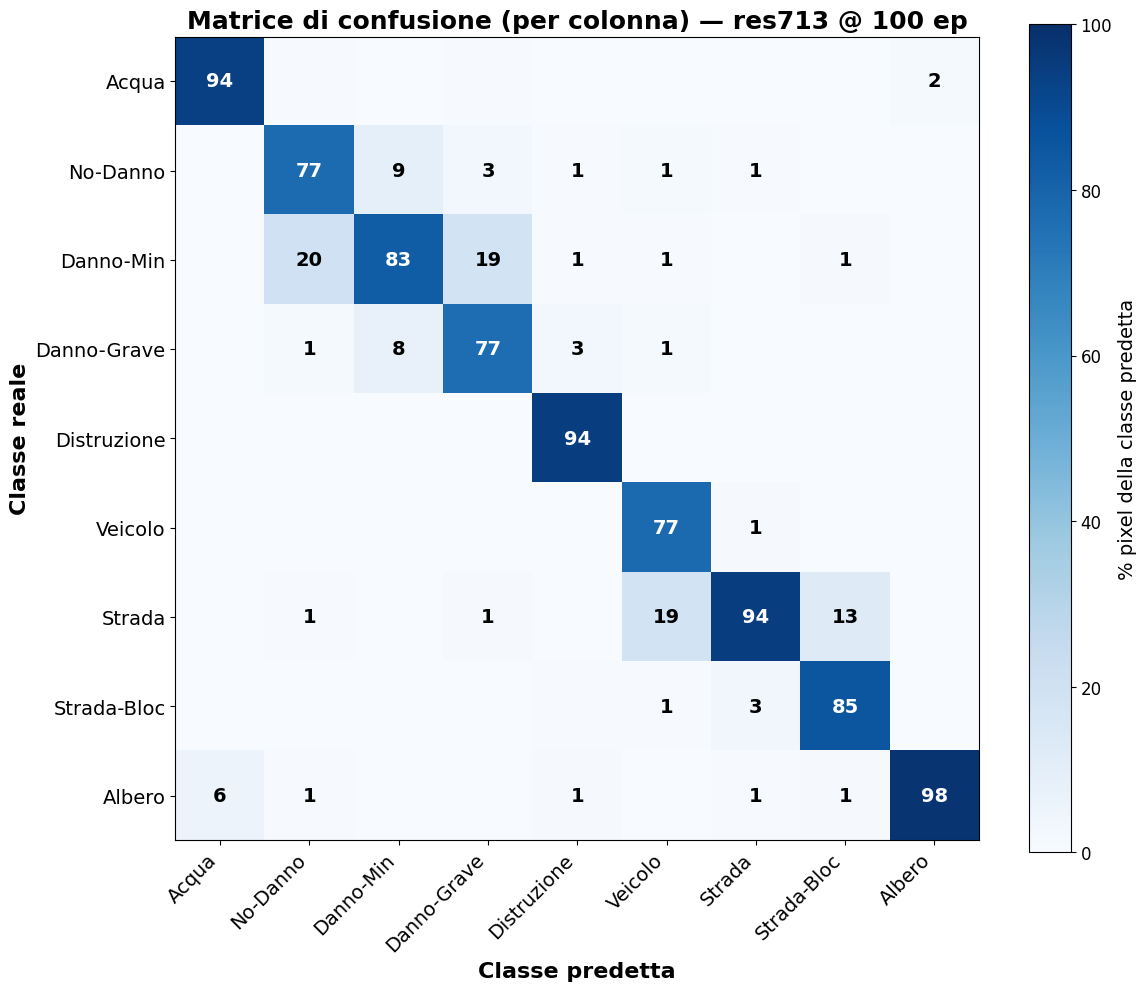

Somma per colonna (interi mostrati): [100 100 100 100 100 100 100 100 100]


In [ ]:
# ============================================================================
# 2.1b · Matrice di confusione fra classi (% per COLONNA, somma esatta 100)
# ============================================================================
import numpy as np
import matplotlib.pyplot as plt

# stesse classi presenti della cella per-riga
presenti = [i for i in range(1, NC) if cm[i].sum() > 0]
cm_v   = cm[np.ix_(presenti, presenti)]
nomi_v = [NOMI[i] for i in presenti]
NCv    = len(presenti)

# --- normalizzazione per COLONNA in percentuale (float) ---
cm_pct = cm_v / cm_v.sum(axis=0, keepdims=True).clip(min=1) * 100

def arrotonda_a_100(vett):
    tot = int(round(vett.sum()))
    if tot == 0:
        return np.zeros_like(vett, dtype=int)
    giu = np.floor(vett).astype(int)
    resto = int(tot - giu.sum())
    if resto > 0:
        ordine = np.argsort(-(vett - giu))
        for idx in ordine[:resto]:
            giu[idx] += 1
    elif resto < 0:
        ordine = np.argsort(vett - giu)
        for idx in ordine[:(-resto)]:
            giu[idx] -= 1
    return giu

# arrotondamento per COLONNA: applico la funzione a ogni colonna
cm_int = np.column_stack([arrotonda_a_100(cm_pct[:,c]) for c in range(NCv)])

fig, ax = plt.subplots(figsize=(12,10))
im = ax.imshow(cm_pct, cmap='Blues', vmin=0, vmax=100)
ax.set_xticks(range(NCv)); ax.set_xticklabels(nomi_v, rotation=45, ha='right', fontsize=14)
ax.set_yticks(range(NCv)); ax.set_yticklabels(nomi_v, fontsize=14)
ax.set_xlabel('Classe predetta', fontweight='bold', fontsize=16)
ax.set_ylabel('Classe reale', fontweight='bold', fontsize=16)
ax.set_title(f'Matrice di confusione (per colonna) — {REGIME} @ {EP_CM} ep', fontweight='bold', fontsize=18)
for i in range(NCv):
    for j in range(NCv):
        v = cm_int[i,j]
        if v >= 1:
            ax.text(j,i,f'{v:d}',ha='center',va='center',
                    color='white' if cm_pct[i,j]>50 else 'black', fontsize=14, fontweight='bold')
cbar = plt.colorbar(im); cbar.set_label('% pixel della classe predetta', fontsize=14)
cbar.ax.tick_params(labelsize=12)
ax.grid(False); plt.tight_layout(); plt.show()

print("Somma per colonna (interi mostrati):", cm_int.sum(axis=0))

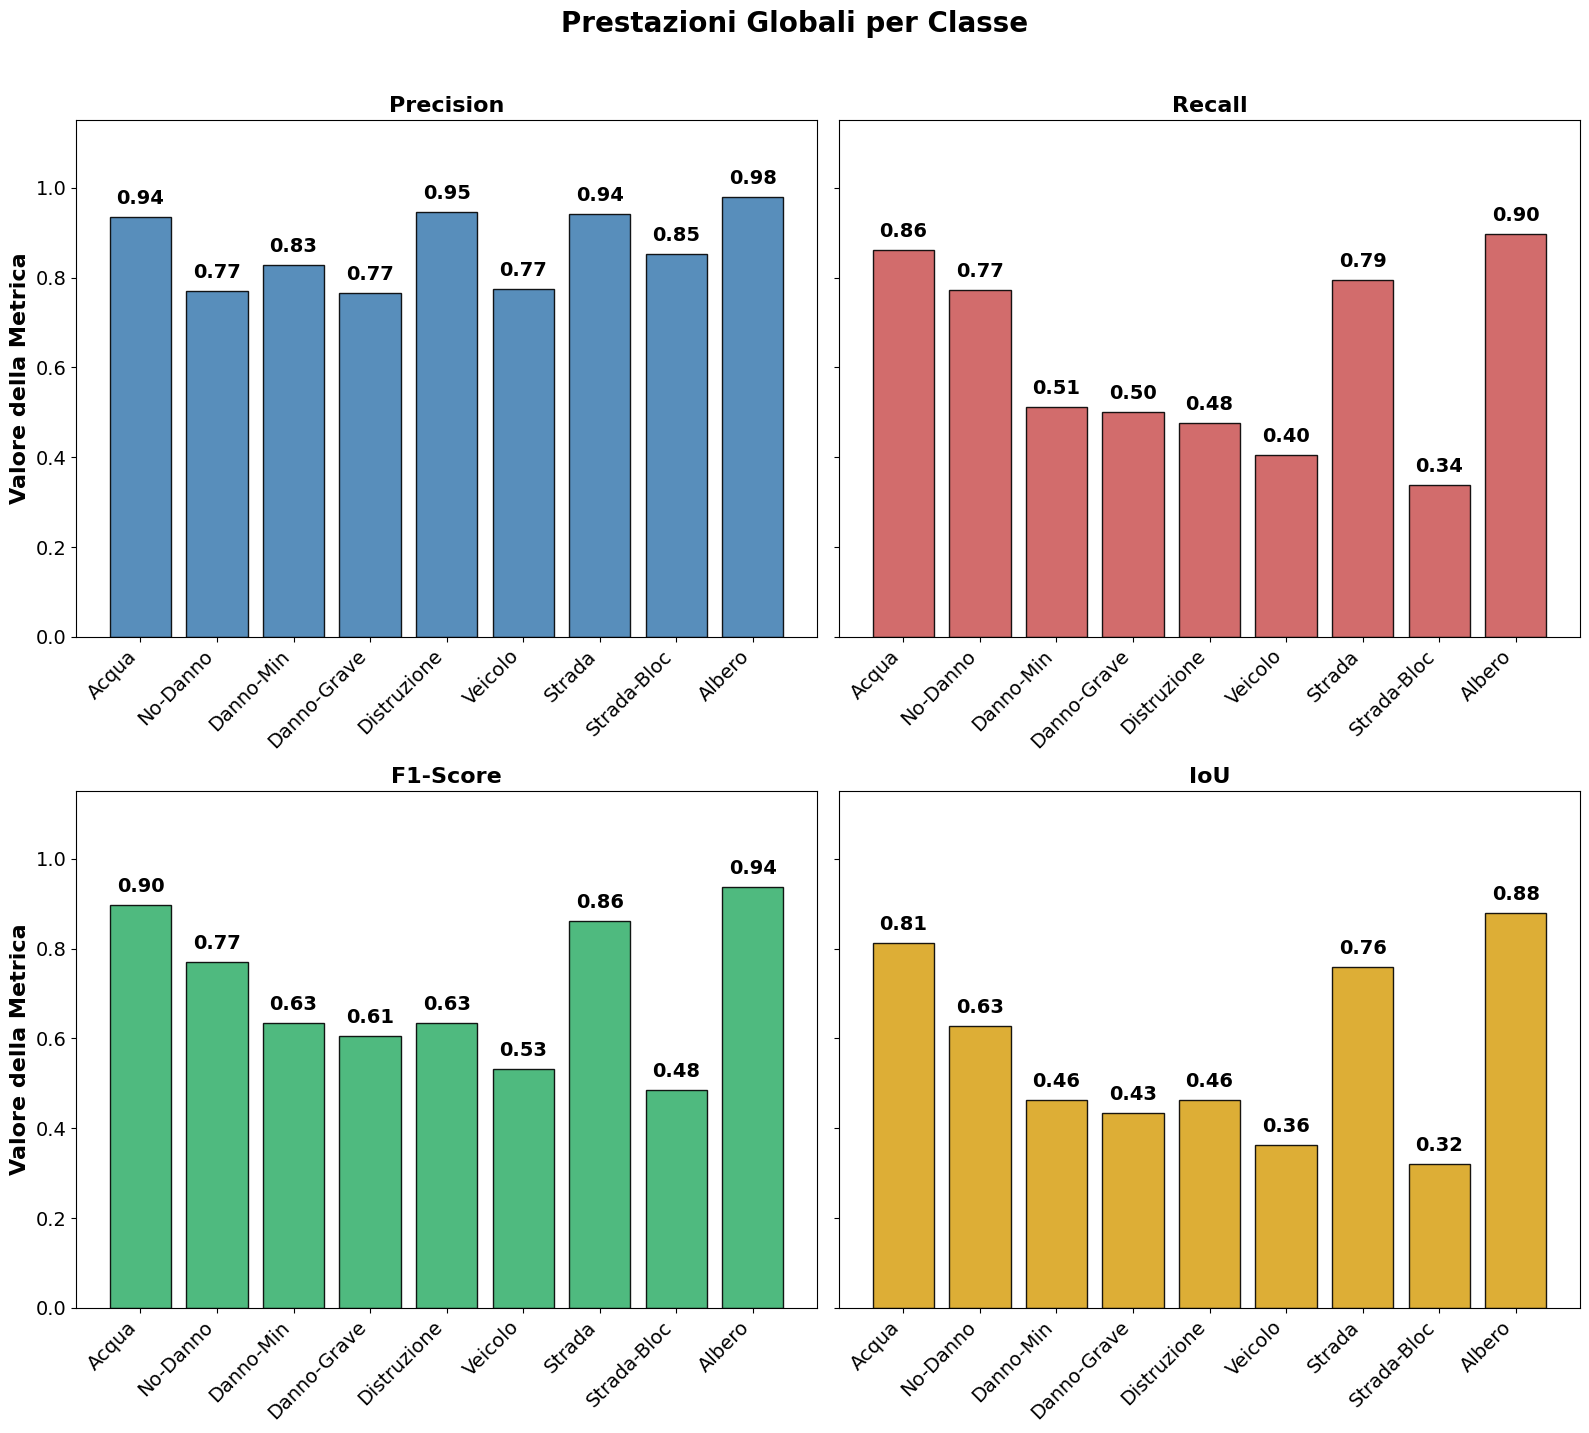

In [ ]:
# ============================================================================
# 2.2 · Metriche di performance fra classi
# ============================================================================

# 1. Calcolo delle metriche globali dalla matrice di confusione (cm) calcolata in 2.1
tp = np.diag(cm).astype(float)
fp = cm.sum(axis=0) - tp
fn = cm.sum(axis=1) - tp

precision = np.divide(tp, tp + fp, out=np.zeros_like(tp), where=(tp + fp) > 0)
recall = np.divide(tp, tp + fn, out=np.zeros_like(tp), where=(tp + fn) > 0)
f1 = np.divide(2 * precision * recall, precision + recall, out=np.zeros_like(tp), where=(precision + recall) > 0)
iou = np.divide(tp, tp + fp + fn, out=np.zeros_like(tp), where=(tp + fp + fn) > 0)

# 2. Filtro solo per le classi effettivamente presenti
prec_v = precision[presenti]
rec_v  = recall[presenti]
f1_v   = f1[presenti]
iou_v  = iou[presenti]

NCv = len(presenti)
x = np.arange(NCv)


fig, axes = plt.subplots(2, 2, figsize=(16, 14), sharey=True)
axes = axes.flatten()

metriche_plot = [
    (prec_v, 'Precision', 'steelblue'),
    (rec_v, 'Recall', 'indianred'),
    (f1_v, 'F1-Score', 'mediumseagreen'),
    (iou_v, 'IoU', 'goldenrod')
]

for ax, (metrica_val, titolo, colore) in zip(axes, metriche_plot):
    ax.bar(x, metrica_val, color=colore, edgecolor='black', alpha=0.9)

    # Impostazioni assi
    ax.set_xticks(x)
    ax.set_xticklabels(nomi_v, rotation=45, ha='right', fontsize=14)
    ax.tick_params(axis='y', labelsize=14)

    # Titolo del subplot
    ax.set_title(titolo, fontweight='bold', fontsize=16)

    ax.set_ylim(0, 1.15)
    ax.grid(False)

    for i, v in enumerate(metrica_val):
        ax.text(i, v + 0.02, f'{v:.2f}', ha='center', va='bottom',
                fontsize=14, fontweight='bold')

# Etichette asse Y (solo sui grafici di sinistra della griglia 2x2)
axes[0].set_ylabel('Valore della Metrica', fontsize=16, fontweight='bold')
axes[2].set_ylabel('Valore della Metrica', fontsize=16, fontweight='bold')

plt.suptitle('Prestazioni Globali per Classe', fontsize=20, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

Calcolo dell'IoU per singola immagine (classi di interesse)...


/tmp/ipykernel_2258/1658410029.py:70: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Classe', y='IoU_per_immagine', data=df_plot, order=ordine_classi,
/tmp/ipykernel_2258/1658410029.py:75: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=45, ha='right', fontsize=10)
/tmp/ipykernel_2258/1658410029.py:78: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Classe', y='IoU_per_immagine', data=df_plot, order=ordine_classi,
/tmp/ipykernel_2258/1658410029.py:83: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_tic

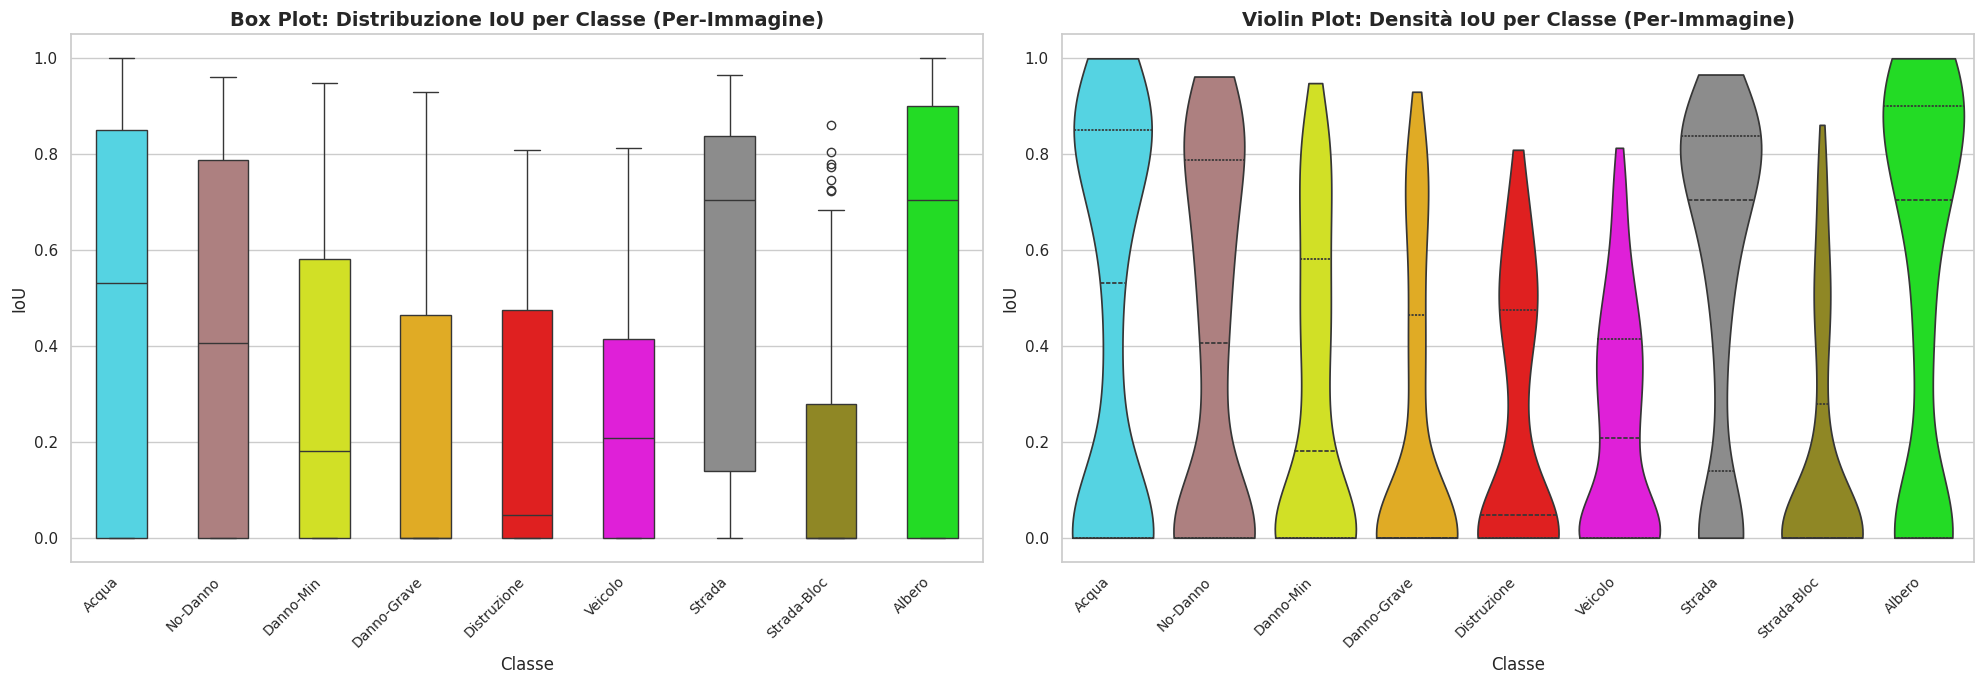


--- Classi incluse nel grafico con colori ufficiali ---
  Acqua                         : 241 immagini
  No-Danno                      : 272 immagini
  Danno-Min                     : 237 immagini
  Danno-Grave                   : 178 immagini
  Distruzione                   : 117 immagini
  Veicolo                       : 209 immagini
  Strada                        : 327 immagini
  Strada-Bloc                   : 119 immagini
  Albero                        : 296 immagini


In [ ]:
# ============================================================================
# 2.3 · Distribuzione IoU per singola immagine (Violin e Box Plot)
# ============================================================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

ious_per_classe = {}

print("Calcolo dell'IoU per singola immagine (classi di interesse)...")
maschere = maschere_di(PRED_DIR)

for m in maschere:
    base = m[:-4]
    gtp = os.path.join(GT_DIR, base + '_lab.png')
    if not os.path.exists(gtp): continue

    # 1. Carica e mappa la predizione
    pred_arr = np.array(Image.open(os.path.join(PRED_DIR, m)).convert('RGB'))
    pred = to_idx(pred_arr)

    # 2. Carica e mappa il Ground Truth
    gt_arr = np.array(Image.open(gtp).convert('RGB'))
    gt = to_idx(gt_arr)

    # 3. Riscala il Ground Truth per allinearlo alla predizione (Metodo PyTorch)
    if gt.shape != pred.shape:
        gt = np.array(Image.fromarray(gt).resize((pred.shape[1], pred.shape[0]), Image.NEAREST))

    # Calcolo IoU saltando lo Sfondo (idx 0) e la Piscina
    for idx, (nome, col) in enumerate(CLASSI):
        if idx == 0: continue
        if nome.lower() == 'piscina': continue

        pm, gm = (pred == idx), (gt == idx)
        un = np.logical_or(pm, gm).sum()
        if un > 0:
            it = np.logical_and(pm, gm).sum()
            if nome not in ious_per_classe:
                ious_per_classe[nome] = []
            ious_per_classe[nome].append(it / un)

# Creazione del DataFrame pulito (esclude classi con 0 immagini valide)
data_list = []
palette_colori = {}

# Converto i colori RGB 0-255 in formato esadecimale per Seaborn
def rgb_a_hex(rgb):
    return '#{:02x}{:02x}{:02x}'.format(rgb[0], rgb[1], rgb[2])

for nome, col in CLASSI:
    if nome in ious_per_classe and len(ious_per_classe[nome]) > 0:
        palette_colori[nome] = rgb_a_hex(col)
        for val in ious_per_classe[nome]:
            data_list.append({'Classe': nome, 'IoU_per_immagine': val})

df_plot = pd.DataFrame(data_list)
ordine_classi = list(palette_colori.keys())

# ============================================================================
# PLOTTING CON I COLORI DELLA LEGENDA
# ============================================================================
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(1, 2, figsize=(20, 7))

# 1. Box Plot
sns.boxplot(x='Classe', y='IoU_per_immagine', data=df_plot, order=ordine_classi,
            ax=ax[0], palette=palette_colori, width=0.5)
ax[0].set_title('Box Plot: Distribuzione IoU per Classe (Per-Immagine)', fontweight='bold', fontsize=14)
ax[0].set_ylim(-0.05, 1.05)
ax[0].set_ylabel('IoU', fontsize=12)
ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=45, ha='right', fontsize=10)

# 2. Violin Plot
sns.violinplot(x='Classe', y='IoU_per_immagine', data=df_plot, order=ordine_classi,
               ax=ax[1], palette=palette_colori, inner='quartile', cut=0)
ax[1].set_title('Violin Plot: Densità IoU per Classe (Per-Immagine)', fontweight='bold', fontsize=14)
ax[1].set_ylim(-0.05, 1.05)
ax[1].set_ylabel('IoU', fontsize=12)
ax[1].set_xticklabels(ax[1].get_xticklabels(), rotation=45, ha='right', fontsize=10)

plt.tight_layout()
plt.show()

print("\n--- Classi incluse nel grafico con colori ufficiali ---")
for nome in ordine_classi:
    print(f"  {nome:30s}: {len(ious_per_classe[nome])} immagini")

Bootstrap su 450 immagini — modello res713 @ 100 epoche

  mIoU medio:             0.4907
  IC 95% (bootstrap):     [0.4700, 0.5097]
  Ampiezza intervallo:    0.0396
  Deviazione std boot:    0.0099


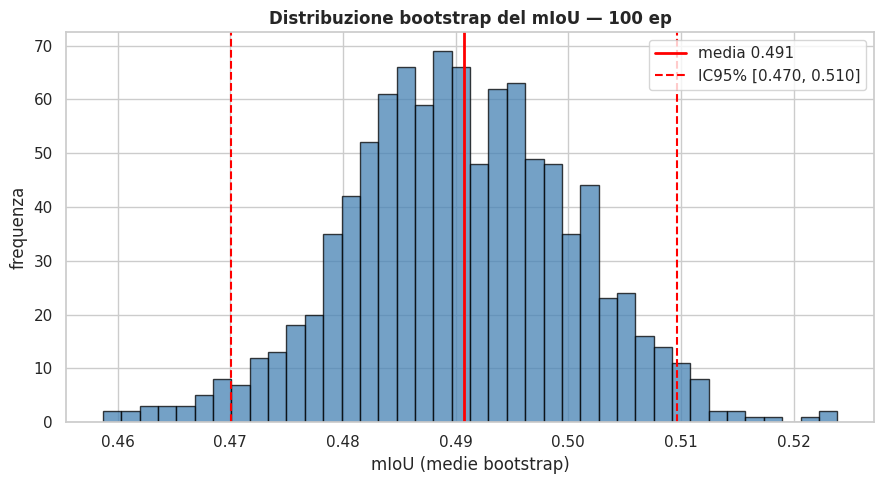


Nota: questo mIoU è la media degli mIoU per-immagine (dal CSV), utile per
stimarne l'incertezza. Puo differire leggermente dal mIoU ufficiale aggregato
di test.py, che pesa i pixel su tutto il set invece di mediare per immagine.


In [ ]:
# ============================================================================
# 2.4 · Intervallo di confidenza del mIoU (bootstrap)
# ============================================================================
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

# Usa il mIoU per immagine dal CSV del modello selezionato (cella 1: df, EPOCHE)
iou_img = pd.to_numeric(df['mIoU_immagine'], errors='coerce').dropna().values
n = len(iou_img)
print(f"Bootstrap su {n} immagini — modello {REGIME} @ {EPOCHE} epoche")

rng = np.random.default_rng(0)
B = 1000
boot = np.array([rng.choice(iou_img, size=n, replace=True).mean() for _ in range(B)])
lo, hi = np.percentile(boot, [2.5, 97.5])
media = iou_img.mean()

print(f"\n  mIoU medio:             {media:.4f}")
print(f"  IC 95% (bootstrap):     [{lo:.4f}, {hi:.4f}]")
print(f"  Ampiezza intervallo:    {hi-lo:.4f}")
print(f"  Deviazione std boot:    {boot.std():.4f}")

fig, ax = plt.subplots(figsize=(9,5))
ax.hist(boot, bins=40, edgecolor='black', alpha=.75, color='steelblue')
ax.axvline(media, color='red', ls='-', lw=2, label=f'media {media:.3f}')
ax.axvline(lo, color='red', ls='--', label=f'IC95% [{lo:.3f}, {hi:.3f}]')
ax.axvline(hi, color='red', ls='--')
ax.set_xlabel('mIoU (medie bootstrap)'); ax.set_ylabel('frequenza')
ax.set_title(f'Distribuzione bootstrap del mIoU — {EPOCHE} ep', fontweight='bold')
ax.legend(); plt.tight_layout(); plt.show()

print("\nNota: questo mIoU è la media degli mIoU per-immagine (dal CSV), utile per")
print("stimarne l'incertezza. Puo differire leggermente dal mIoU ufficiale aggregato")
print("di test.py, che pesa i pixel su tutto il set invece di mediare per immagine.")

--- Confronto diretto ---
  Modello res713 @ 100 ep:  0.8809
  Paper RescueNet (Benchmark): 0.9567
  Differenza: -0.0758


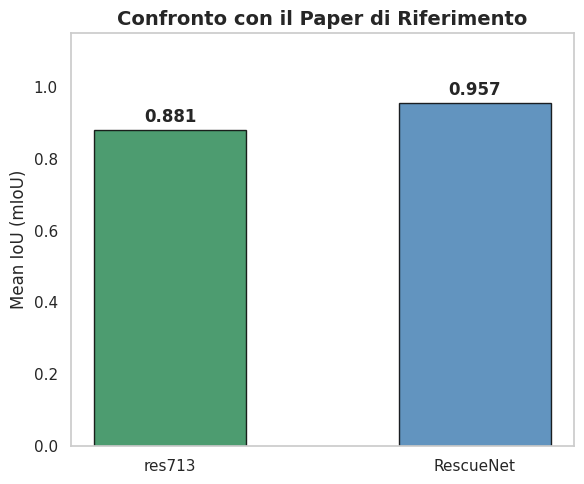

In [ ]:
# ============================================================================
# 2.5 · Confronto diretto: Mio Modello vs Paper RescueNet
# ============================================================================
import numpy as np
import matplotlib.pyplot as plt

# 1. Recupero del mIoU del mio modello (Globale Ufficiale o ricalcolato senza sfondo)
if 'global_miou' in globals() and global_miou is not None:
    miou_modello = global_miou
else:
    tp = np.diag(cm).astype(float)
    fp = cm.sum(axis=0) - tp
    fn = cm.sum(axis=1) - tp
    iou_modello_arr = np.divide(tp, tp + fp + fn, out=np.zeros(NC), where=(tp + fp + fn) > 0)
    valid_classes = [i for i in range(1, NC) if cm[i].sum() > 0]
    miou_modello = iou_modello_arr[valid_classes].mean()

# 2. Valore di riferimento del Paper RescueNet
MIOU_PAPER = 0.9567

print(f"--- Confronto diretto ---")
print(f"  Modello {REGIME} @ {EPOCHE} ep:  {miou_modello:.4f}")
print(f"  Paper RescueNet (Benchmark): {MIOU_PAPER:.4f}")
print(f"  Differenza: {miou_modello - MIOU_PAPER:+.4f}")

# Creazione del grafico a 2 colonne
etich = [f'{REGIME}', 'RescueNet']
vals = [miou_modello, MIOU_PAPER]
col = ['seagreen', 'steelblue']

fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(etich, vals, color=col, edgecolor='black', alpha=0.85, width=0.5)

for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2.0, yval + 0.01, f'{yval:.3f}', ha='center', va='bottom', fontweight='bold')

ax.set_ylabel('Mean IoU (mIoU)', fontsize=12)
ax.set_title('Confronto con il Paper di Riferimento', fontweight='bold', fontsize=14)
ax.set_ylim(0, 1.15) # Margine superiore per le etichette
ax.grid(False)
plt.tight_layout()
plt.show()

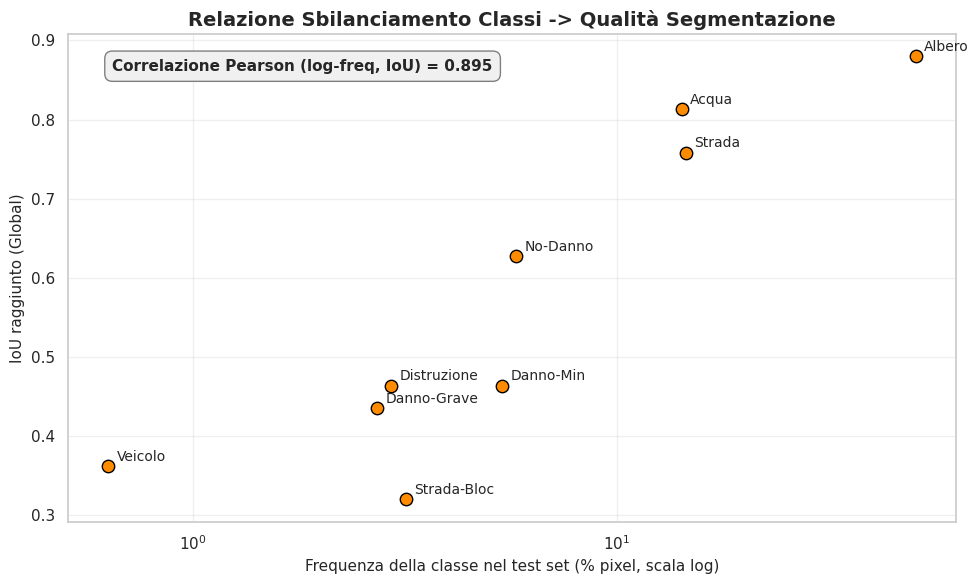

In [ ]:
# ============================================================================
# 2.6 · Sbilanciamento del dataset: frequenza classe vs IoU
# ============================================================================
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# 1. Filtro le classi: ignoro lo Sfondo (indice 0) e le classi vuote
classi_valide = [i for i in range(1, NC) if cm[i].sum() > 0]
nomi_validi = [NOMI[i] for i in classi_valide]

# 2. Calcolo Frequenza (%) e IoU solo per le classi valide
tot_pixel_validi = cm[classi_valide].sum()
freq_pct = (cm[classi_valide].sum(axis=1) / tot_pixel_validi) * 100

tp = np.diag(cm).astype(float)
fp = cm.sum(axis=0) - tp
fn = cm.sum(axis=1) - tp
iou_tutte = np.divide(tp, tp + fp + fn, out=np.zeros(NC), where=(tp + fp + fn) > 0)
iou = iou_tutte[classi_valide]

# 3. Disegno del grafico a dispersione
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(freq_pct, iou, s=80, color='darkorange', edgecolor='black', zorder=3)

# Aggiunta delle etichette per ogni punto
for i, n in enumerate(nomi_validi):
    ax.annotate(n, (freq_pct[i], iou[i]), fontsize=10,
                xytext=(6, 4), textcoords='offset points')

ax.set_xscale('log')
ax.set_xlabel('Frequenza della classe nel test set (% pixel, scala log)', fontsize=11)
ax.set_ylabel('IoU raggiunto (Global)', fontsize=11)
ax.set_title('Relazione Sbilanciamento Classi -> Qualità Segmentazione', fontweight='bold', fontsize=14)
ax.grid(alpha=0.3, zorder=0)

# 4. Calcolo della correlazione di Pearson (log-frequenza vs IoU)
mask = freq_pct > 0
if mask.sum() > 1:
    r = pearsonr(np.log10(freq_pct[mask]), iou[mask])[0]
    ax.text(0.05, 0.95, f'Correlazione Pearson (log-freq, IoU) = {r:.3f}',
            transform=ax.transAxes, va='top', fontsize=11, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='#f0f0f0', edgecolor='gray'))

plt.tight_layout()
plt.show()

--- Tabella metriche ufficiali estratte (10 epoche trovate) ---
 Epoche   mIoU  IoU_Number of classes to predict  IoU_Train dataset size  IoU_Class weights  IoU_28.3671,  4.6486, 49.1156], device='cuda  IoU_(module)
     10 0.4806                              11.0                  3595.0                NaN                                           NaN           NaN
     20 0.5690                              11.0                  3595.0                NaN                                           NaN           NaN
     30 0.6226                              11.0                  3595.0                NaN                                           NaN           NaN
     40 0.7236                              11.0                  3595.0                NaN                                           NaN           NaN
     50 0.7696                              11.0                  3595.0                NaN                                           NaN           NaN
     60 0.8120          

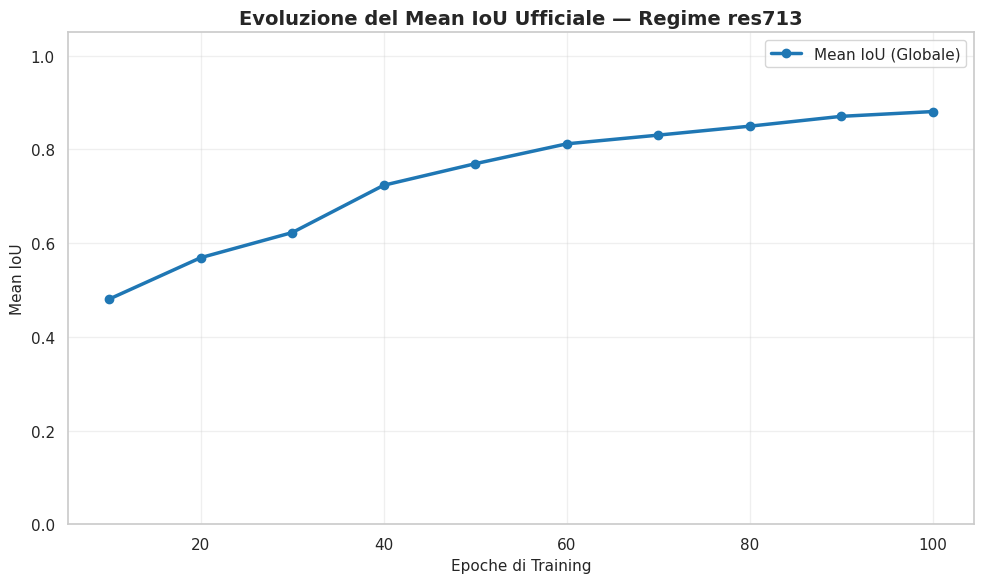


--- Variazione IoU per classe dall'epoca 10 all'epoca 100 ---
  road-blocked                   +0.8070
  pool                           +0.7775
  building-major-damage          +0.6805
  building-medium-damage         +0.4469
  building-total-destruction     +0.3916
  vehicle                        +0.3232
  building-no-damage             +0.2932
  road-clear                     +0.1670
  water                          +0.0891
  tree                           +0.0272
  Number of classes to predict   +0.0000
  Train dataset size             +0.0000


In [ ]:
# ============================================================================
# 3.1 · Evoluzione delle metriche ufficiali al crescere delle epoche (Parsing dai file .txt)
# ============================================================================
import os, re, glob
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

# 1. Ricerca dei file di log testuali salvati in precedenza
txt_files = sorted(glob.glob(f'{DRIVE_BASE}/metriche_{REGIME}_ep*.txt'))

metriche_parseate = {}

for fpath in txt_files:
    # Estrae il numero dell'epoca dal nome del file (es. metriche_res713_ep100.txt -> 100)
    m_ep = re.search(r'_ep(\d+)\.txt$', fpath)
    if not m_ep: continue
    ep = int(m_ep.group(1))

    dati_epoca = {'Epoche': ep}

    with open(fpath, 'r') as f:
        for line in f:
            line = line.strip()
            # Cerca la riga del Mean IoU globale (es. ">>>> Avg. loss: 0.4296 | Mean IoU: 0.8809")
            if "Mean IoU:" in line:
                m_miou = re.search(r'Mean IoU:\s*([0-9.]+)', line)
                if m_miou:
                    dati_epoca['mIoU'] = float(m_miou.group(1))

            # Cerca le righe delle singole classi (es. "water: 0.9675" o "unlabeled: nan")
            elif ":" in line and not line.startswith(">>>>") and not line.startswith("DataParallel") and not line.startswith("tensor"):
                parts = line.split(":")
                if len(parts) == 2:
                    cls_name = parts[0].strip()
                    val_str = parts[1].strip()
                    try:
                        dati_epoca[f'IoU_{cls_name}'] = float(val_str)
                    except ValueError:
                        # Gestisce eventuali valori 'nan'
                        dati_epoca[f'IoU_{cls_name}'] = np.nan

    if 'mIoU' in dati_epoca:
        metriche_parseate[ep] = dati_epoca

# 2. Creazione del DataFrame storico
if len(metriche_parseate) < 1:
    print(f"Nessun file di log .txt valido trovato in {DRIVE_BASE} per il regime {REGIME}.")
else:
    ep_ord = sorted(metriche_parseate.keys())
    tab = pd.DataFrame([metriche_parseate[e] for e in ep_ord])

    print(f"--- Tabella metriche ufficiali estratte ({len(ep_ord)} epoche trovate) ---")
    cols_vis = ['Epoche', 'mIoU'] + [c for c in tab.columns if c.startswith('IoU_')][:5] # Mostra Epoca, mIoU e prime classi
    print(tab[[c for c in cols_vis if c in tab.columns]].to_string(index=False))

    # --- Grafico: mIoU globale vs epoche ---
    fig, ax = plt.subplots(figsize=(10, 6))
    if 'mIoU' in tab.columns:
        ax.plot(tab['Epoche'], tab['mIoU'], 'o-', label='Mean IoU (Globale)', color='tab:blue', linewidth=2.5, markersize=6)

    ax.set_title(f'Evoluzione del Mean IoU Ufficiale — Regime {REGIME}', fontweight='bold', fontsize=14)
    ax.set_xlabel('Epoche di Training', fontsize=11)
    ax.set_ylabel('Mean IoU', fontsize=11)
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=11)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    # --- Analisi testuale dei guadagni per classe ---
    classi_iou = [c for c in tab.columns if c.startswith('IoU_')]
    if len(ep_ord) > 1 and classi_iou:
        primo, ultimo = tab.iloc[0], tab.iloc[-1]
        print(f"\n--- Variazione IoU per classe dall'epoca {int(primo['Epoche'])} all'epoca {int(ultimo['Epoche'])} ---")
        guadagni = {c.replace('IoU_', ''): ultimo[c] - primo[c] for c in classi_iou if not np.isnan(primo[c]) and not np.isnan(ultimo[c])}
        for nome, g in sorted(guadagni.items(), key=lambda x: -x[1]):
            print(f"  {nome:30s} {g:+.4f}")
    elif len(ep_ord) == 1:
        print("\nNota: è disponibile un solo checkpoint salvato. Per vedere l'evoluzione grafica e temporale, occorre avere i log di più epoche.")

Epoche res713 trovate: [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
Epoche res385 caricate automaticamente dal CSV: [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]


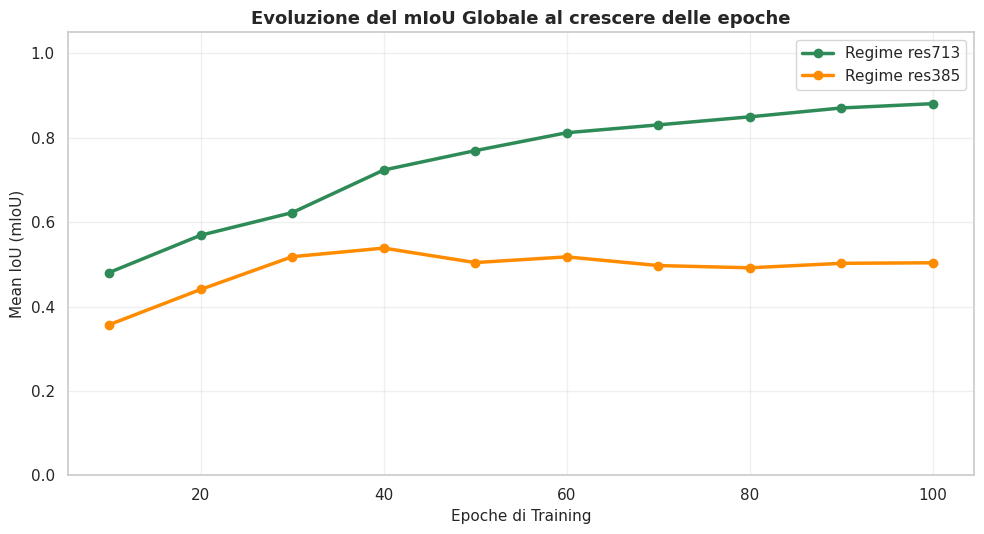

In [ ]:
# ============================================================================
# 3.2 · Evoluzione Temporale del mIoU Globale (res713 txt & res385 csv)
# ============================================================================
import os, re, glob
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

# 1. Parsing dei file .txt ufficiali per res713
txt_files_713 = sorted(glob.glob(f'{DRIVE_BASE}/metriche_res713_ep*.txt'))
metriche_713 = {}

for fpath in txt_files_713:
    m_ep = re.search(r'_ep(\d+)\.txt$', fpath)
    if not m_ep: continue
    ep = int(m_ep.group(1))

    with open(fpath, 'r') as f:
        for line in f:
            line = line.strip()
            if "Mean IoU:" in line:
                m_miou = re.search(r'Mean IoU:\s*([0-9.]+)', line)
                if m_miou:
                    metriche_713[ep] = float(m_miou.group(1))

print(f"Epoche res713 trovate: {sorted(metriche_713.keys())}")

# 2. Lettura automatica res385 dal file CSV
csv_385_path = f'{DRIVE_BASE}/miou_res385_ogni10.csv'

# Legge il CSV in automatico riconoscendo gli header 'epoca' e 'mean_iou'
df_385 = pd.read_csv(csv_385_path)

# Trasforma le colonne del DataFrame in un dizionario per allinearsi al resto del codice
metriche_385 = dict(zip(df_385['epoca'], df_385['mean_iou']))

print(f"Epoche res385 caricate automaticamente dal CSV: {sorted(metriche_385.keys())}")

# 3. Plot dell'evoluzione temporale del mIoU
fig, ax = plt.subplots(figsize=(10, 5.5))

# Plot res713
if metriche_713:
    ep_713 = sorted(metriche_713.keys())
    val_713 = [metriche_713[e] for e in ep_713]
    ax.plot(ep_713, val_713, 'o-', color='seagreen', linewidth=2.5, markersize=6, label='Regime res713')

# Plot res385
if metriche_385:
    ep_385 = sorted(metriche_385.keys())
    val_385 = [metriche_385[e] for e in ep_385]
    ax.plot(ep_385, val_385, 'o-', color='darkorange', linewidth=2.5, markersize=6, label='Regime res385')

ax.set_title('Evoluzione del mIoU Globale al crescere delle epoche', fontsize=13, fontweight='bold')
ax.set_xlabel('Epoche di Training', fontsize=11)
ax.set_ylabel('Mean IoU (mIoU)', fontsize=11)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

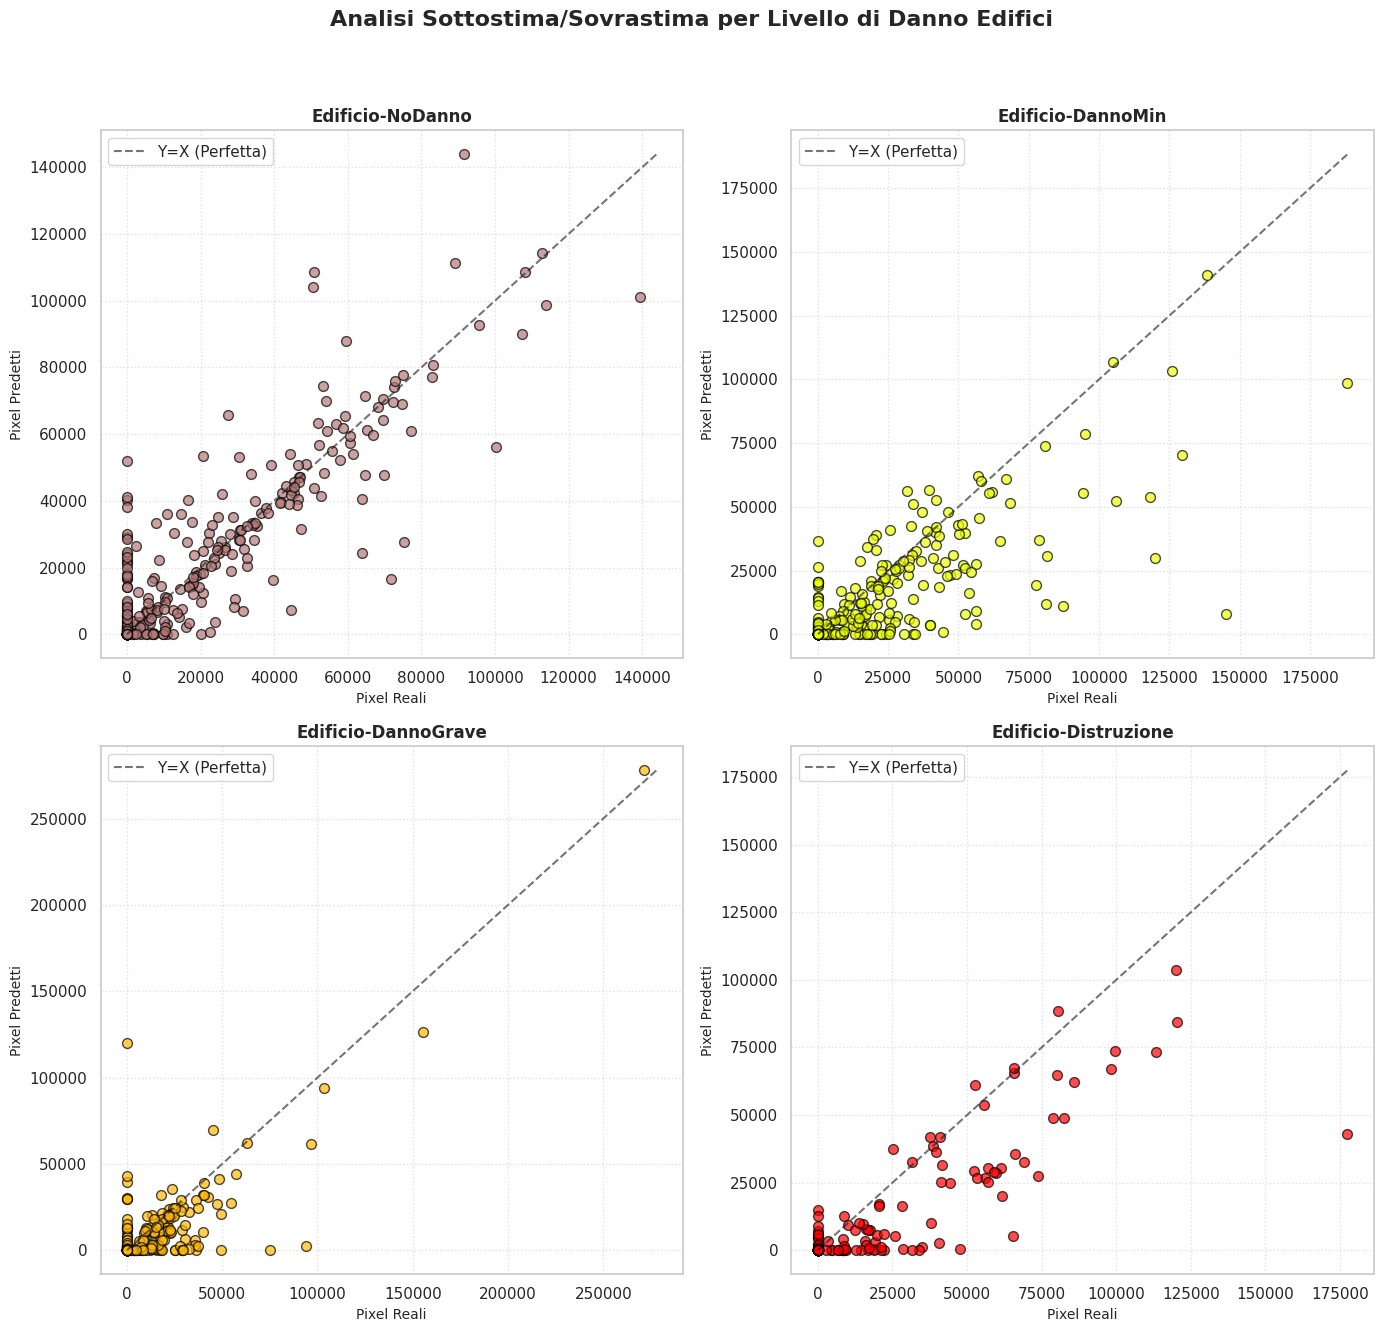

In [ ]:
# ============================================================================
# 3.4 · Scatter plot di Analisi Sottostima/Sovrastima per Livello di Danno Edifici
# ============================================================================

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

# 1. Caricamento del DataFrame dfc (Coincidenze Classi) usando le costanti globali
csv_path = f'{DRIVE_BASE}/coincidenze_classi_{REGIME}_ep{EPOCHE}.csv'
if not os.path.exists(csv_path):
    raise FileNotFoundError(f"Impossibile trovare il file: {csv_path}\nAssicurati di aver generato il CSV delle coincidenze.")

dfc = pd.read_csv(csv_path)

# Le 4 classi degli edifici e i loro rispettivi colori RGB (normalizzati per Matplotlib)
classi_edifici = [
    'Edificio-NoDanno',
    'Edificio-DannoMin',
    'Edificio-DannoGrave',
    'Edificio-Distruzione'
]
colori_edifici = [
    (180/255, 120/255, 120/255),  # Marrone/Grigio
    (235/255, 255/255, 7/255),    # Giallo
    (255/255, 184/255, 6/255),    # Arancione
    (255/255, 0, 0)               # Rosso
]

# Crea una figura con una griglia 2x2
fig, axes = plt.subplots(2, 2, figsize=(14, 14))

# Cicla attraverso i 4 assi, le classi e i colori
for ax, classe, colore in zip(axes.flat, classi_edifici, colori_edifici):
    col_reali = f'reali_{classe}'
    col_pred = f'predetti_{classe}'

    if col_reali in dfc.columns and col_pred in dfc.columns:
        # Disegna lo scatter plot
        ax.scatter(dfc[col_reali], dfc[col_pred], color=colore, alpha=0.7, edgecolors='black', s=50)

        # Linea diagonale Y=X (Previsione Perfetta)
        max_val = max(dfc[col_reali].max(), dfc[col_pred].max())
        if pd.isna(max_val) or max_val == 0:
            max_val = 100 # Default se la classe è totalmente vuota

        ax.plot([0, max_val], [0, max_val], 'k--', alpha=0.6, label='Y=X (Perfetta)')

        # Formattazione del singolo grafico
        ax.set_xlabel('Pixel Reali', fontsize=10)
        ax.set_ylabel('Pixel Predetti', fontsize=10)
        ax.set_title(f'{classe}', fontweight='bold', fontsize=12)
        ax.grid(True, linestyle=':', alpha=0.6)
        ax.legend(loc='upper left')
    else:
        ax.text(0.5, 0.5, f"Dati mancanti per\n{classe}", ha='center', va='center')

# Titolo generale e impaginazione
plt.suptitle("Analisi Sottostima/Sovrastima per Livello di Danno Edifici", fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

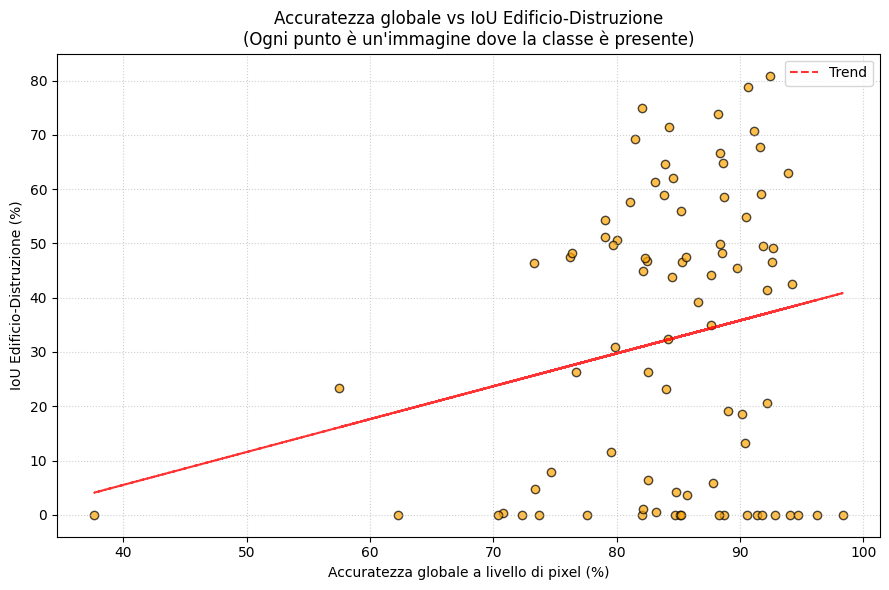

In [ ]:
# ============================================================================
# 3.5 · Scatter plot Accurtatezza globale
# ============================================================================

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

classe_critica = 'Edificio-Distruzione'
col_iou = f'IoU_{classe_critica}'
col_acc = 'coincidenza_totale_%'

# Converto in numerico (le stringhe vuote '' diventano NaN) e rimuovo i NaN
df_plot = dfc.copy()
df_plot[col_iou] = pd.to_numeric(df_plot[col_iou], errors='coerce')
df_plot = df_plot.dropna(subset=[col_iou])

plt.figure(figsize=(9, 6))
plt.scatter(df_plot[col_acc], df_plot[col_iou], color='orange', alpha=0.7, edgecolors='black')

# Aggiunta linea di tendenza
if len(df_plot) > 1:
    z = np.polyfit(df_plot[col_acc], df_plot[col_iou], 1)
    p = np.poly1d(z)
    plt.plot(df_plot[col_acc], p(df_plot[col_acc]), "r--", alpha=0.8, label='Trend')

plt.xlabel('Accuratezza globale a livello di pixel (%)')
plt.ylabel(f'IoU {classe_critica} (%)')
plt.title(f'Accuratezza globale vs IoU {classe_critica}\n(Ogni punto è un\'immagine dove la classe è presente)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

Epoche disponibili: [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
Modello: res713 @ 100 epoche



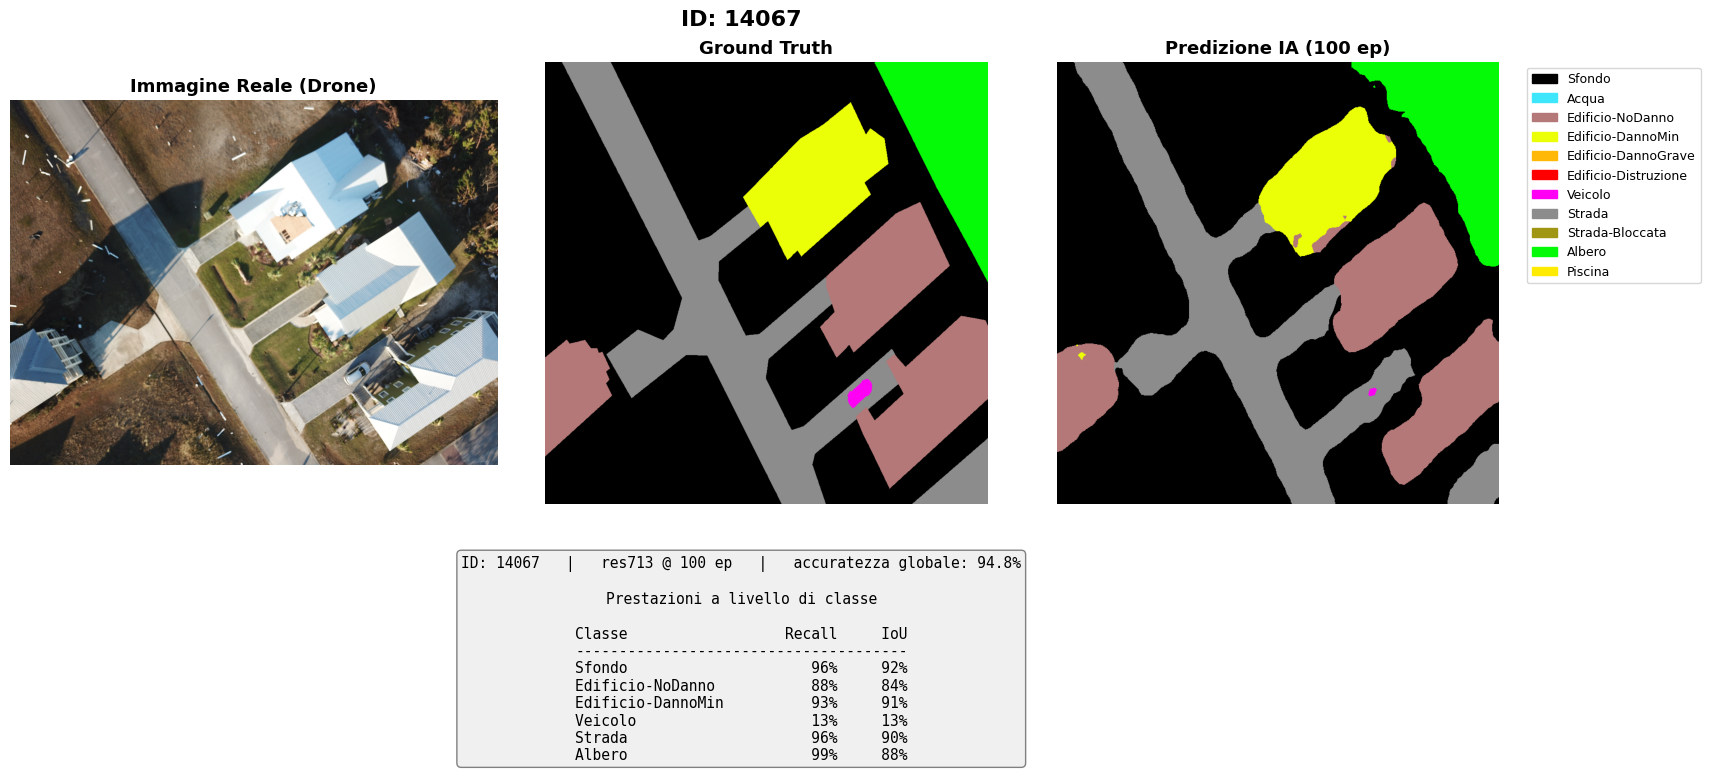

In [ ]:
# ============================================================================
# 4.1 · Confronto visivo originale | ground truth | predizione + coincidenze
# ============================================================================
import os, re, glob, random
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image

orig_dir = f'{DRIVE_BASE}/test_originali'
gt_dir   = f'{DRIVE_BASE}/colormasks'          # ground truth colorate (_lab.png)

INTERATTIVO  = False        # True = chiede l'epoca da tastiera
EPOCA_SCELTA = None         # se non interattivo: None = epoca più alta
MODALITA     = 'id'         # 'id' oppure 'random'
IMMAGINE_ID  = '14067'
SEED         = None         # numero per riproducibilità, None = casuale
MOSTRA_IOU   = True         # False per togliere la colonna IoU

# --- Epoca ---
cart = sorted(glob.glob(f'{DRIVE_BASE}/predictions_{REGIME}_ep*'),
              key=lambda p: int(re.search(r'_ep(\d+)$', p).group(1)))
epoche = [int(re.search(r'_ep(\d+)$', c).group(1)) for c in cart]
if not epoche:
    raise SystemExit(f"Nessuna cartella predictions_{REGIME}_ep*.")

print(f"Epoche disponibili: {epoche}")
if INTERATTIVO:
    s = input(f"Quale epoca? (invio = {max(epoche)}): ").strip()
    EPOCA = int(s) if s else max(epoche)
else:
    EPOCA = EPOCA_SCELTA if EPOCA_SCELTA is not None else max(epoche)
pred_dir = f'{DRIVE_BASE}/predictions_{REGIME}_ep{EPOCA}'
print(f"Modello: {REGIME} @ {EPOCA} epoche\n")

# --- Immagine ---
disp = sorted(f[:-4] for f in os.listdir(pred_dir) if f.endswith('.png'))
if MODALITA == 'random':
    if SEED is not None: random.seed(SEED)
    IMMAGINE_ID = random.choice(disp)
    print(f"Immagine a caso: {IMMAGINE_ID}")
elif IMMAGINE_ID not in disp:
    raise SystemExit(f"Immagine '{IMMAGINE_ID}' non trovata. Esempi: {disp[:8]}")

def apri(c, nome, exts):
    for e in exts:
        p = os.path.join(c, nome+e)
        if os.path.exists(p): return Image.open(p)
    return None

img_org  = apri(orig_dir, IMMAGINE_ID, ['.jpg','.JPG','.png'])
img_gt   = apri(gt_dir,   IMMAGINE_ID+'_lab', ['.png','.jpg'])
img_pred = apri(pred_dir, IMMAGINE_ID, ['.png'])
if img_org is None:  raise SystemExit(f"Originale non trovato in {orig_dir}")
if img_pred is None: raise SystemExit(f"Predizione non trovata in {pred_dir}")
if img_gt is None:   print(f"Ground truth '{IMMAGINE_ID}_lab.png' non trovata in {gt_dir}")

COLORI = {
    (0,0,0):'Sfondo',(61,230,250):'Acqua',(180,120,120):'Edificio-NoDanno',
    (235,255,7):'Edificio-DannoMin',(255,184,6):'Edificio-DannoGrave',
    (255,0,0):'Edificio-Distruzione',(255,0,245):'Veicolo',
    (140,140,140):'Strada',(160,150,20):'Strada-Bloccata',
    (4,250,7):'Albero',(255,235,0):'Piscina'
}

# --- Coincidenze dal CSV (lookup robusto stringa-vs-stringa) ---
csv_path = f'{DRIVE_BASE}/coincidenze_classi_{REGIME}_ep{EPOCA}.csv'
header = f"ID: {IMMAGINE_ID}   |   {REGIME} @ {EPOCA} ep"
linee = []
if not os.path.exists(csv_path):
    linee.append(f"CSV non trovato: esegui prima la cella di analisi")
else:
    dfc = pd.read_csv(csv_path, dtype={'ID_Immagine': str})
    riga = dfc[dfc['ID_Immagine'].astype(str) == str(IMMAGINE_ID)]
    if riga.empty:
        linee.append(f"ATTENZIONE: {IMMAGINE_ID} non presente nel CSV")
    else:
        riga = riga.iloc[0]
        tot = riga.get('coincidenza_totale_%', None)
        if pd.notna(tot):
            header += f"   |   accuratezza globale: {float(tot):.1f}%"
        if MOSTRA_IOU:
            linee.append(f"{'Classe':<22}{'Recall':>8}{'IoU':>8}")
            linee.append("-" * 38)
        else:
            linee.append(f"{'Classe':<22}{'Recall':>8}")
            linee.append("-" * 30)
        for nome in COLORI.values():
            cc = riga.get(f'coinc_{nome}', '')
            if pd.isna(cc) or str(cc).strip() == '':
                continue
            if MOSTRA_IOU:
                iu = riga.get(f'IoU_{nome}', '')
                iu_txt = f"{float(iu):.0f}%" if pd.notna(iu) and str(iu).strip() != '' else "-"
                linee.append(f"{nome:<22}{float(cc):>7.0f}%{iu_txt:>8}")
            else:
                linee.append(f"{nome:<22}{float(cc):>7.0f}%")

testo = (header + "\n\nPrestazioni a livello di classe\n\n"
         + "\n".join(linee))

# --- Plot ---
pann = [(img_org,"Immagine Reale (Drone)")]
if img_gt is not None: pann.append((img_gt,"Ground Truth"))
pann.append((img_pred, f"Predizione IA ({EPOCA} ep)"))

fig, axes = plt.subplots(1, len(pann), figsize=(6.5*len(pann), 6.5))
if len(pann)==1: axes=[axes]
for ax,(im,t) in zip(axes,pann):
    if im is not None: ax.imshow(im)
    ax.set_title(t, fontsize=13, fontweight='bold'); ax.axis('off')
fig.suptitle(f"ID: {IMMAGINE_ID}", fontsize=16, fontweight='bold', y=0.98)

patches=[mpatches.Patch(color='#%02x%02x%02x'%rgb,label=l) for rgb,l in COLORI.items()]
axes[-1].legend(handles=patches, bbox_to_anchor=(1.05,1), loc=2, fontsize=9)

fig.text(0.5, 0.14, testo, ha='center', va='top', fontsize=10.5, family='monospace',
         bbox=dict(boxstyle='round', facecolor='#f0f0f0', edgecolor='gray'))
plt.subplots_adjust(bottom=0.22, top=0.90, wspace=0.05)
plt.show()

I 4 casi con mIoU più basso — res713 @ 100 ep



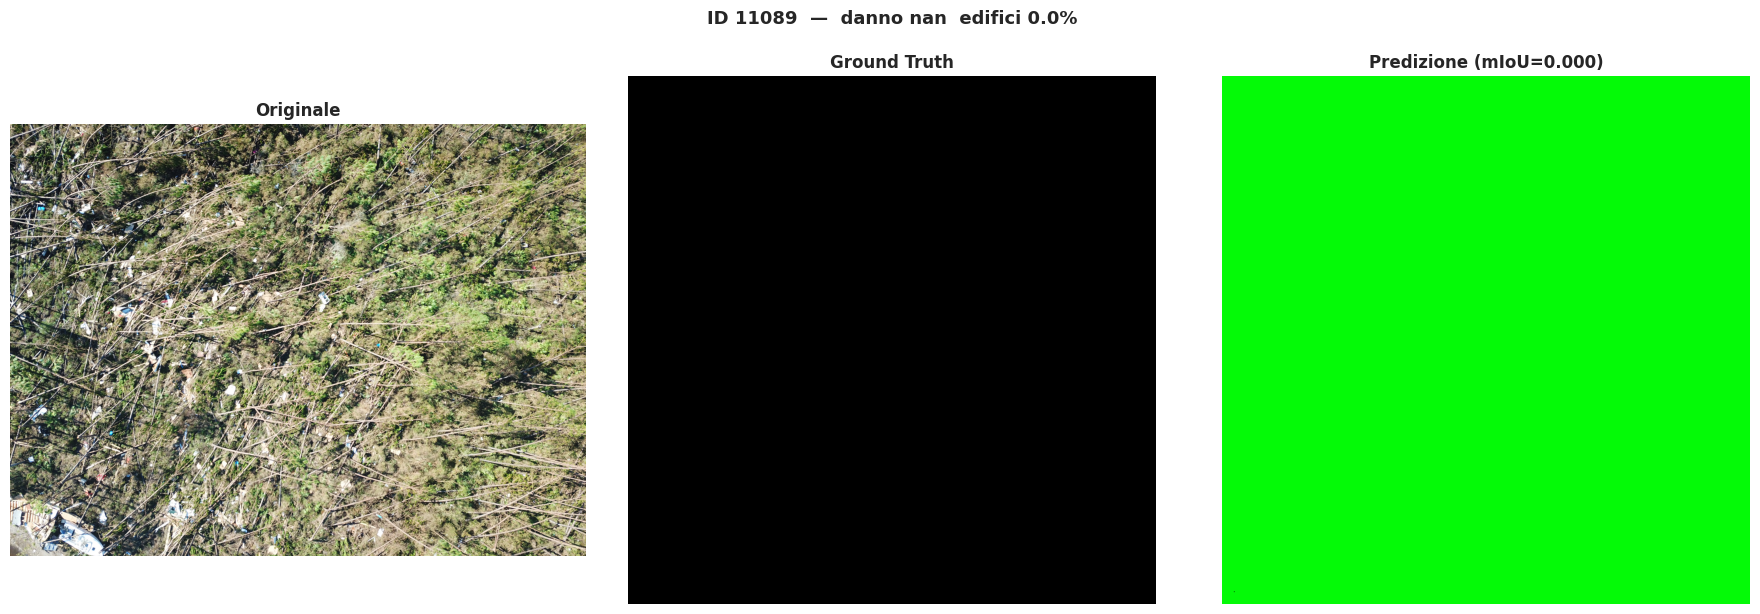

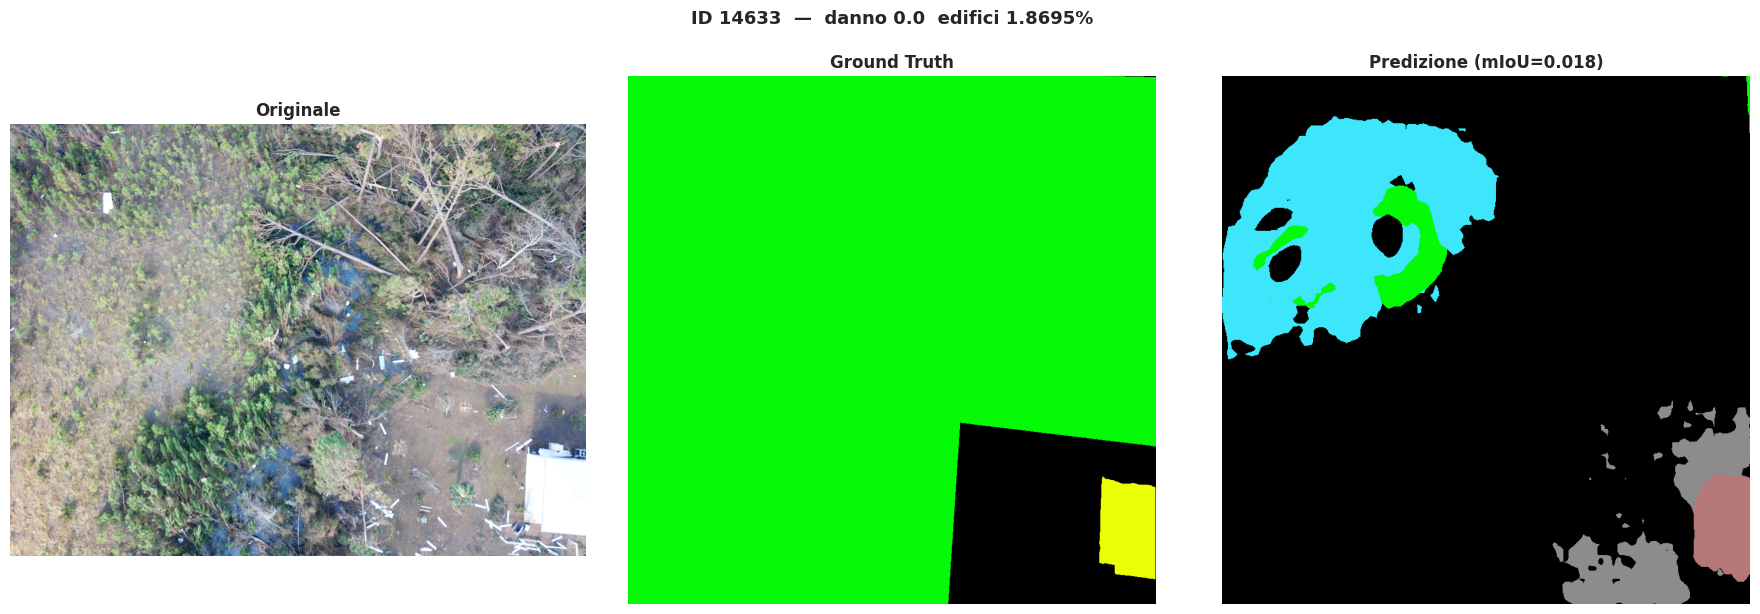

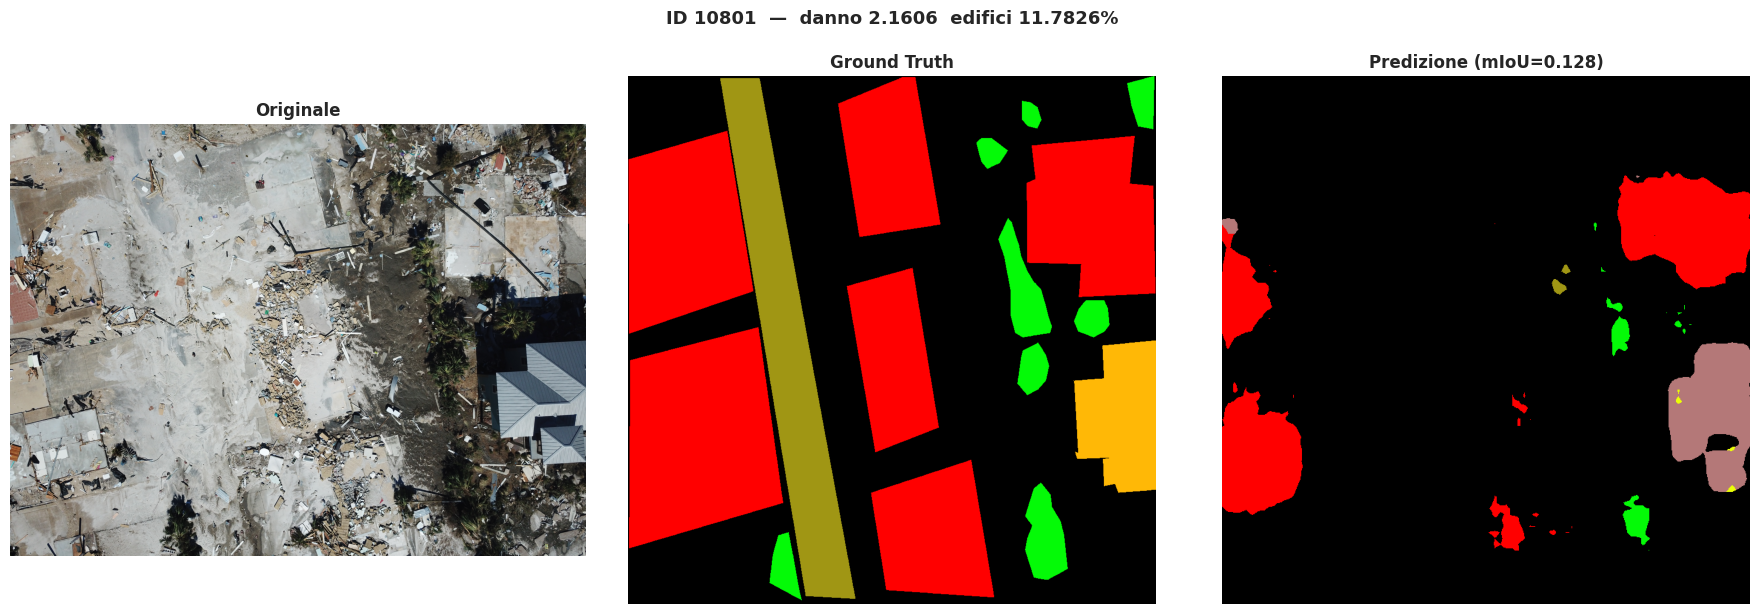

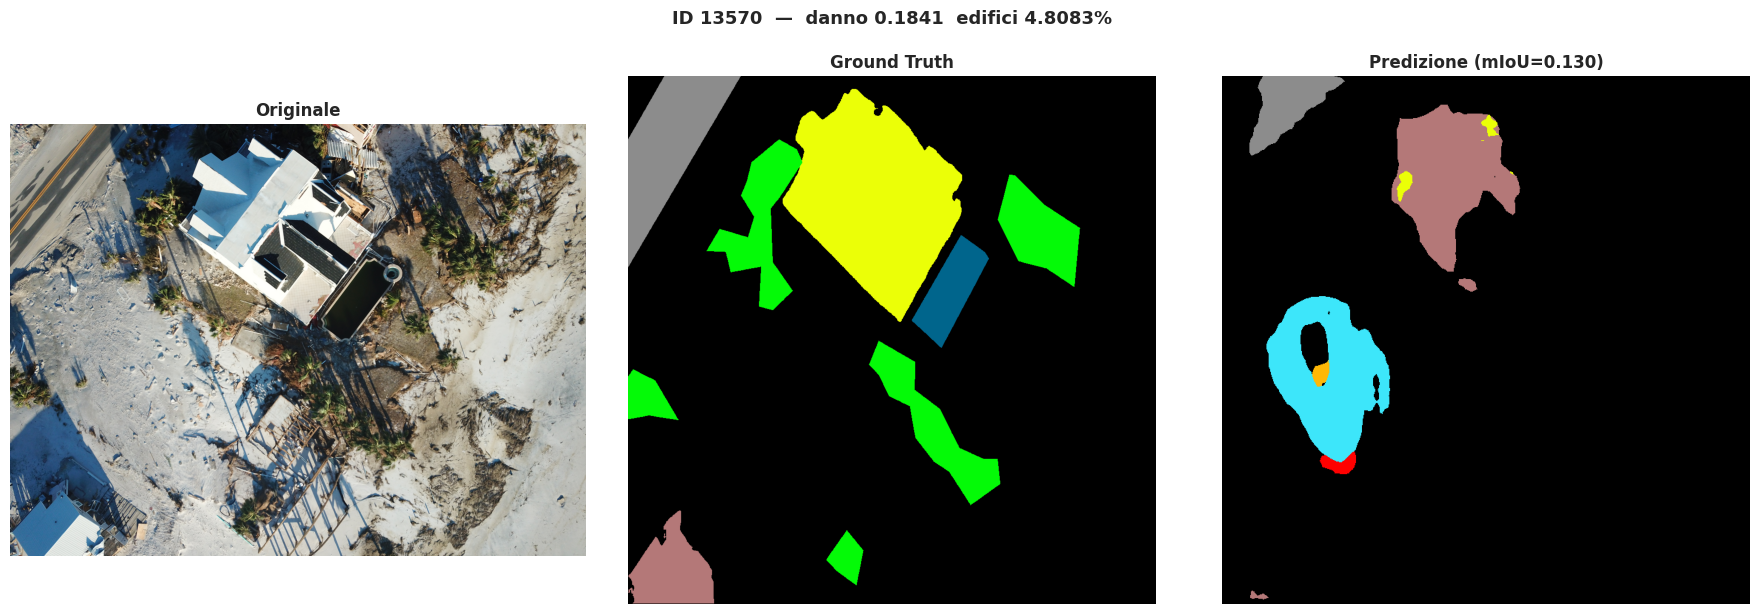

In [ ]:
# ============================================================================
# 4.2 · Analisi qualitativa degli errori: i casi peggiori
# ============================================================================
import os, glob, re
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

orig_dir = f'{DRIVE_BASE}/test_originali'
gt_dir   = f'{DRIVE_BASE}/colormasks'
cart = glob.glob(f'{DRIVE_BASE}/predictions_{REGIME}_ep*')
PRED_DIR = max(cart, key=lambda p:int(re.search(r'_ep(\d+)$',p).group(1)))

N_PEGGIORI = 4
iou_col = pd.to_numeric(df['mIoU_immagine'], errors='coerce')
peggiori = df.assign(_iou=iou_col).nsmallest(N_PEGGIORI, '_iou')

def apri(cartella, nome, exts):
    for e in exts:
        p = os.path.join(cartella, nome+e)
        if os.path.exists(p): return Image.open(p)
    return None

print(f"I {N_PEGGIORI} casi con mIoU più basso — {REGIME} @ {EPOCHE} ep\n")
for _, riga in peggiori.iterrows():
    idv = str(riga['ID_Immagine'])
    img = apri(orig_dir, idv, ['.jpg','.JPG','.png'])
    gt  = apri(gt_dir, idv+'_lab', ['.png','.jpg'])
    pr  = apri(PRED_DIR, idv, ['.png'])
    if img is None or pr is None:
        print(f"  {idv}: file mancante, salto"); continue

    pann = [(img,'Originale')]
    if gt is not None: pann.append((gt,'Ground Truth'))
    pann.append((pr, f"Predizione (mIoU={riga['_iou']:.3f})"))
    fig, axes = plt.subplots(1, len(pann), figsize=(6*len(pann), 6))
    if len(pann)==1: axes=[axes]
    for ax,(im,t) in zip(axes,pann):
        ax.imshow(im); ax.set_title(t, fontsize=12, fontweight='bold'); ax.axis('off')
    fig.suptitle(f"ID {idv}  —  danno {riga.get('Danno_Edifici_0_3','?')}  "
                 f"edifici {riga.get('Perc_Edifici_Totale','?')}%",
                 fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout(); plt.show()


Validazione indice di rischio — res713 @ 100 epoche

  100/450...
  200/450...
  300/450...
  400/450...

--- Rischio predetto vs rischio reale (n=450) ---
  Correlazione Pearson:  0.852
  Correlazione Spearman: 0.866  (ordine relativo)
  Errore medio assoluto: 8.30
  Rischio medio reale:   17.89   predetto: 10.84


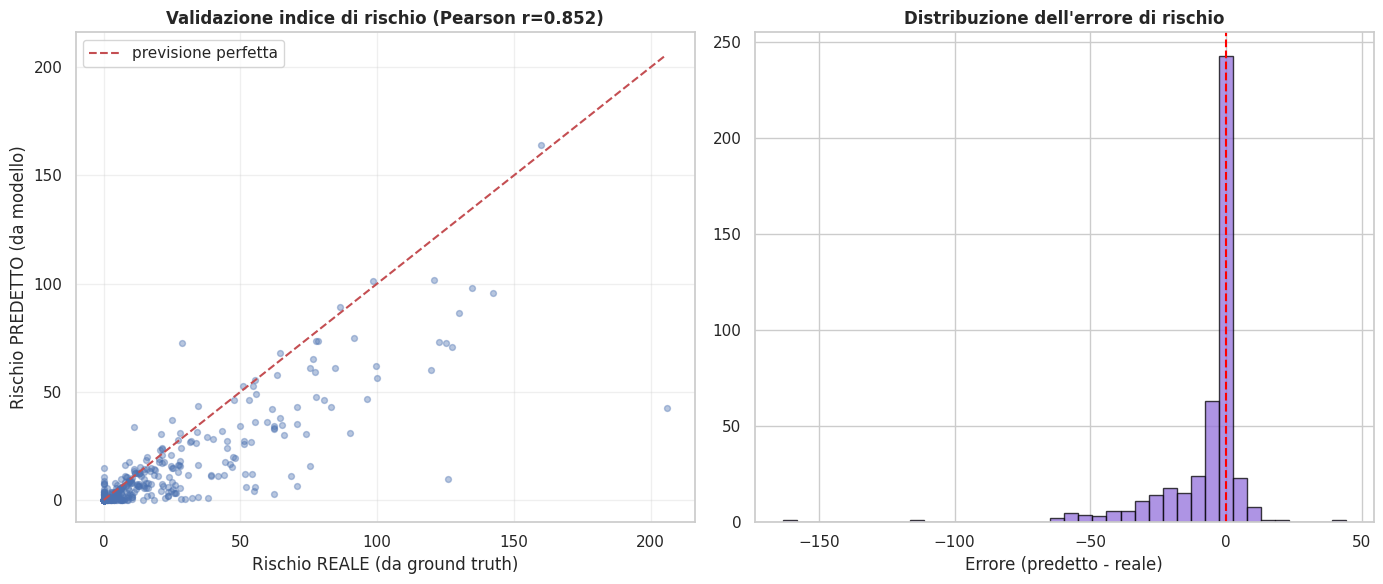

In [ ]:
# ============================================================================
# 5.1 · Validazione dell'indice di rischio contro le ground truth
# ============================================================================

import os, glob, re
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from scipy import stats

cart = glob.glob(f'{DRIVE_BASE}/predictions_{REGIME}_ep*')
PRED_DIR = max(cart, key=lambda p:int(re.search(r'_ep(\d+)$',p).group(1)))
EP_V = int(re.search(r'_ep(\d+)$', PRED_DIR).group(1))
GT_DIR = f'{DRIVE_BASE}/colormasks'
print(f"Validazione indice di rischio — {REGIME} @ {EP_V} epoche\n")

COLORI = {(180,120,120):'No',(235,255,7):'Min',(255,184,6):'Grave',
          (255,0,0):'Distr',(160,150,20):'StradaBloc'}
PESI = {'No':0,'Min':1,'Grave':3,'Distr':5,'StradaBloc':2.5}

def rischio(arr):
    tot = arr.shape[0]*arr.shape[1]
    cols,cnts = np.unique(arr.reshape(-1,3),axis=0,return_counts=True)
    r=0.0
    for c,n in zip(cols,cnts):
        t=tuple(int(x) for x in c)
        if t in COLORI: r += (n/tot*100)*PESI[COLORI[t]]
    return r

r_pred, r_gt, ids = [], [], []
maschere = sorted(f for f in os.listdir(PRED_DIR) if f.endswith('.png'))
for k,m in enumerate(maschere,1):
    base=m[:-4]; gtp=os.path.join(GT_DIR,base+'_lab.png')
    if not os.path.exists(gtp): continue
    rp = rischio(np.array(Image.open(os.path.join(PRED_DIR,m)).convert('RGB')))
    rg = rischio(np.array(Image.open(gtp).convert('RGB')))
    r_pred.append(rp); r_gt.append(rg); ids.append(base)
    if k%100==0: print(f"  {k}/{len(maschere)}...")

r_pred=np.array(r_pred); r_gt=np.array(r_gt)
pear = stats.pearsonr(r_gt, r_pred)[0]
spear = stats.spearmanr(r_gt, r_pred)[0]
mae = np.abs(r_pred-r_gt).mean()

print(f"\n--- Rischio predetto vs rischio reale (n={len(r_pred)}) ---")
print(f"  Correlazione Pearson:  {pear:.3f}")
print(f"  Correlazione Spearman: {spear:.3f}  (ordine relativo)")
print(f"  Errore medio assoluto: {mae:.2f}")
print(f"  Rischio medio reale:   {r_gt.mean():.2f}   predetto: {r_pred.mean():.2f}")

fig, (a1,a2) = plt.subplots(1,2,figsize=(14,6))
a1.scatter(r_gt, r_pred, alpha=.4, s=18)
lim=max(r_gt.max(), r_pred.max())
a1.plot([0,lim],[0,lim],'r--',label='previsione perfetta')
a1.set_xlabel('Rischio REALE (da ground truth)'); a1.set_ylabel('Rischio PREDETTO (da modello)')
a1.set_title(f'Validazione indice di rischio (Pearson r={pear:.3f})', fontweight='bold')
a1.legend(); a1.grid(alpha=.3)

a2.hist(r_pred-r_gt, bins=40, edgecolor='black', alpha=.75, color='mediumpurple')
a2.axvline(0, color='red', ls='--')
a2.set_xlabel('Errore (predetto - reale)'); a2.set_title('Distribuzione dell\'errore di rischio', fontweight='bold')
plt.tight_layout(); plt.show()

In [ ]:
# ============================================================================
# SEZIONE 6 — ADATTAMENTO AI CRITERI AEDES (PROTEZIONE CIVILE)
# Mappatura delle classi RescueNet sui gradi EMS98, classificazione
# bidimensionale gravità x estensione, grado complessivo e validazione
# contro il grado ufficiale del dataset.
# ============================================================================
# 6.1 · Mappatura delle classi RescueNet sui gradi AeDES/EMS98
# Corrispondenza RescueNet -> AeDES (accorpamento dei gradi)
MAP_AEDES = {
    'no':    ('D0',       'Nessun danno'),
    'medio': ('D1-D2',    'Danno lieve-medio'),
    'grave': ('D3',       'Danno grave'),
    'distr': ('D4-D5',    'Crollo parziale/totale'),
}
# peso ordinale del grado (per media pesata e severità)
SEVERITA = {'no':0, 'medio':1, 'grave':2, 'distr':3}

print("Corrispondenza classi RescueNet -> gradi AeDES/EMS98\n")
print(f"{'RescueNet':<14}{'Grado AeDES':<12}{'Descrizione'}")
for k in ORDINE:
    g, desc = MAP_AEDES[k]
    print(f"{k:<14}{g:<12}{desc}")

Corrispondenza classi RescueNet -> gradi AeDES/EMS98

RescueNet     Grado AeDES Descrizione
no            D0          Nessun danno
medio         D1-D2       Danno lieve-medio
grave         D3          Danno grave
distr         D4-D5       Crollo parziale/totale


In [ ]:
# ============================================================================
# 6.2 · Caricamento del grado di danno ufficiale RescueNet (CSV)
# ============================================================

CLASS_CSV_PATH = '/content/drive/MyDrive/RescueNet_Output/rescuenet_damages/RescueNet-classification-test.csv'   # <-- path del CSV su Drive

# Nomi delle 3 classi ufficiali (indice = valore nel CSV)
RN_UFFICIALE = {0: 'Superficial', 1: 'Medium', 2: 'Major'}


COL_ID    = None   # None = usa la 1a colonna come ID
COL_LABEL = None   # None = usa la 2a colonna come label (0/1/2)

df_uff = pd.read_csv(CLASS_CSV_PATH)
print(f"CSV ufficiale caricato: {len(df_uff)} righe, colonne = {list(df_uff.columns)}")

col_id    = COL_ID    if COL_ID    is not None else df_uff.columns[0]
col_label = COL_LABEL if COL_LABEL is not None else df_uff.columns[1]

def _norm_id(x):
    """Normalizza l'ID a stringa senza estensione, per il match con le maschere."""
    s = str(x).strip()
    for e in ('.jpg', '.JPG', '.png', '.PNG'):
        if s.endswith(e): s = s[:-len(e)]
    if s.endswith('_lab'): s = s[:-4]
    return s

# dizionario ID -> classe ufficiale (0/1/2)
GRADO_UFFICIALE = {}
for _, row in df_uff.iterrows():
    GRADO_UFFICIALE[_norm_id(row[col_id])] = int(row[col_label])

print(f"Immagini con grado ufficiale: {len(GRADO_UFFICIALE)}")
print("Distribuzione classi ufficiali:")
_vc = pd.Series(list(GRADO_UFFICIALE.values())).map(RN_UFFICIALE).value_counts()
print(_vc.to_string())


CSV ufficiale caricato: 450 righe, colonne = ['Image_ID', 'Neighborhood_ID']
Immagini con grado ufficiale: 450
Distribuzione classi ufficiali:
Medium         191
Superficial    139
Major          120


In [ ]:
# 6.30 · Grado AeDES complessivo su tutto il test set  ->  CSV su Drive
SOGLIA_SIGN = 1/3   # estensione minima perché un grado determini la classe

def grado_complessivo(conteggi):
    tot = sum(conteggi.values())
    if tot == 0: return None
    # dal più grave al meno grave: primo che supera la soglia
    for k in ['distr','grave','medio']:
        if conteggi[k]/tot >= SOGLIA_SIGN:
            return MAP_AEDES[k][0]
    # nessun grado grave significativo: se c'è danno lieve sopra soglia -> D1-D2
    if conteggi['medio']/tot >= SOGLIA_SIGN:
        return 'D1-D2'
    # danni solo in tracce -> prevale il più grave presente anche se <1/3, ma segnalato
    for k in ['distr','grave','medio']:
        if conteggi[k] > 0:
            return MAP_AEDES[k][0] + ' (traccia)'
    return 'D0'

def grado_pesato(conteggi):
    """Media pesata dei livelli di gravità sui pixel di edificio (scala 0-3)."""
    tot = sum(conteggi.values())
    if tot == 0: return np.nan
    return sum(conteggi[k]*SEVERITA[k] for k in ORDINE) / tot

# Applica a tutto il test set
righe = []
for m in sorted(f for f in os.listdir(PRED_DIR) if f.endswith('.png')):
    base = m[:-4]
    c = conta_edifici(np.array(Image.open(os.path.join(PRED_DIR,m)).convert('RGB')))
    tot = sum(c.values())
    if tot == 0: continue
    r = {'ID': base, 'grado_AeDES': grado_complessivo(c),
         'perc_edifici': round(tot/(np.array(Image.open(os.path.join(PRED_DIR,m))).shape[0]*
                                     np.array(Image.open(os.path.join(PRED_DIR,m))).shape[1])*100, 2)}
    for k in ORDINE:
        r[f'ext_{MAP_AEDES[k][0]}'] = round(c[k]/tot*100, 1)
    righe.append(r)

Immagini confrontate: 345   (senza label ufficiale: 0)

Accuratezza (AeDES vs ufficiale): 50.4%  (n=345)
Sottostime (reale > predetto): 60 (17.4%)  <-- falsi negativi agibilita'
Sovrastime (reale < predetto): 111 (32.2%)  (conservativo)



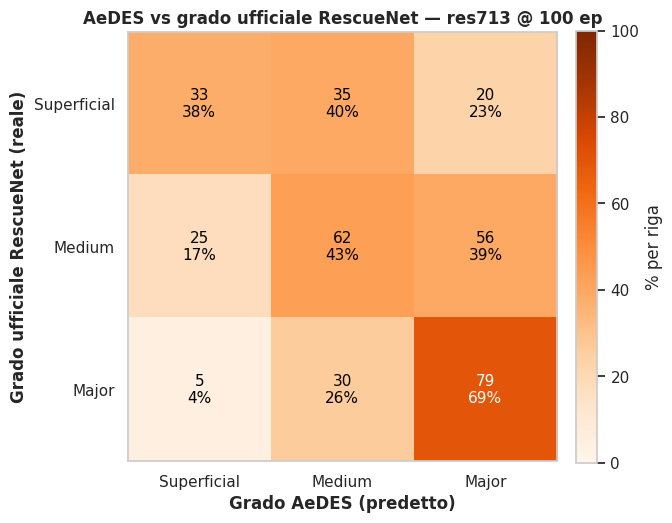

In [ ]:
# ============================================================================
# 6.31 · Matrice di confusione: AeDES (dai pixel) vs grado ufficiale
# ============================================================

AEDES_TO_RN = {
    'D0':    0,   # Nessun danno            -> Superficial
    'D1-D2': 1,   # Danno lieve-medio       -> Medium
    'D3':    2,   # Danno grave             -> Medium
    'D4-D5': 2,   # Crollo parziale/totale  -> Major
}

CLASSI = ['Superficial', 'Medium', 'Major']   # indici 0,1,2

def grado_base(g):   # rimuove ' (traccia)' dal grado AeDES
    return g.replace(' (traccia)', '')

pred, uff = [], []
mancanti = 0
for m in sorted(f for f in os.listdir(PRED_DIR) if f.endswith('.png')):
    base = m[:-4]
    if base not in GRADO_UFFICIALE:      # nessuna label ufficiale per questa immagine
        mancanti += 1
        continue
    cp = conta_edifici(np.array(Image.open(os.path.join(PRED_DIR, m)).convert('RGB')))
    if sum(cp.values()) == 0:            # nessun edificio: niente grado AeDES
        continue
    g_aedes = grado_base(grado_complessivo(cp))   # 'D0'/'D1-D2'/'D3'/'D4-D5'
    if g_aedes not in AEDES_TO_RN:
        continue
    pred.append(AEDES_TO_RN[g_aedes])
    uff.append(GRADO_UFFICIALE[base])

n = len(pred)
print(f"Immagini confrontate: {n}   (senza label ufficiale: {mancanti})\n")

# matrice di confusione 3x3: righe = ufficiale (reale), colonne = AeDES (predetto)
M = np.zeros((3, 3), int)
for a, b in zip(uff, pred):
    M[a, b] += 1

acc   = np.trace(M) / M.sum() * 100 if M.sum() else 0
sotto = np.tril(M, -1).sum()   # reale > predetto -> sottostima
sopra = np.triu(M,  1).sum()   # reale < predetto -> sovrastima
print(f"Accuratezza (AeDES vs ufficiale): {acc:.1f}%  (n={M.sum()})")
print(f"Sottostime (reale > predetto): {sotto} ({sotto/M.sum()*100:.1f}%)  <-- falsi negativi agibilita'")
print(f"Sovrastime (reale < predetto): {sopra} ({sopra/M.sum()*100:.1f}%)  (conservativo)\n")

Mn = M / M.sum(axis=1, keepdims=True).clip(min=1) * 100
fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(Mn, cmap='Oranges', vmin=0, vmax=100)
ax.set_xticks(range(3)); ax.set_xticklabels(CLASSI)
ax.set_yticks(range(3)); ax.set_yticklabels(CLASSI)
ax.set_xlabel('Grado AeDES (predetto)', fontweight='bold')
ax.set_ylabel('Grado ufficiale RescueNet (reale)', fontweight='bold')
for i in range(3):
    for j in range(3):
        ax.text(j, i, f"{M[i,j]}\n{Mn[i,j]:.0f}%", ha='center', va='center',
                color='white' if Mn[i,j] > 55 else 'black', fontsize=11)
ax.set_title(f'AeDES vs grado ufficiale RescueNet — {REGIME} @ {EP} ep', fontweight='bold')
ax.grid(False)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='% per riga')
plt.tight_layout(); plt.show()


Immagini confrontate: 345
  Coincidono: 174 (50.4%)
  Diverse:    171 (49.6%)
     di cui sottostime: 60  |  sovrastime: 111
  (escluse: 0 senza grado ufficiale, 105 senza edifici)


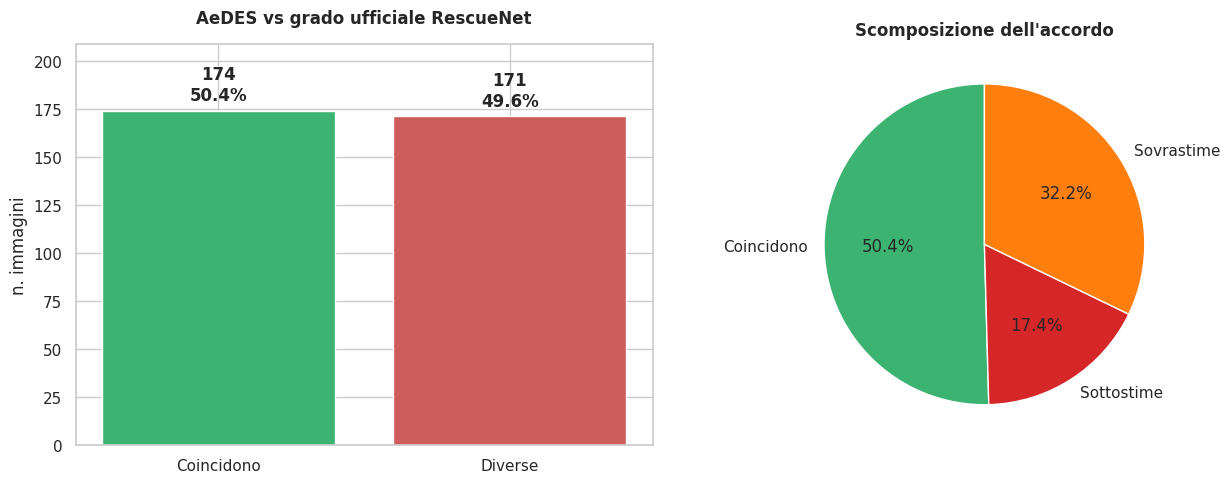

In [ ]:
# ============================================================================
# 6.4 · Accordo aggregato AeDES vs ufficiale (barre + scomposizione)
# ============================================================

uguali, diversi, senza_uff, senza_edif = 0, 0, 0, 0
dettaglio_diff = {'sottostima': 0, 'sovrastima': 0}

for m in sorted(f for f in os.listdir(PRED_DIR) if f.endswith('.png')):
    base = m[:-4]
    cc = conta_edifici(np.array(Image.open(os.path.join(PRED_DIR, m)).convert('RGB')))
    if sum(cc.values()) == 0:
        senza_edif += 1
        continue
    if base not in GRADO_UFFICIALE:
        senza_uff += 1
        continue
    a_idx = AEDES_TO_RN.get(grado_base(grado_complessivo(cc)), None)
    if a_idx is None:
        continue
    u_idx = GRADO_UFFICIALE[base]
    if a_idx == u_idx:
        uguali += 1
    else:
        diversi += 1
        dettaglio_diff['sottostima' if a_idx < u_idx else 'sovrastima'] += 1

tot = uguali + diversi
print(f"Immagini confrontate: {tot}")
print(f"  Coincidono: {uguali} ({uguali/tot*100:.1f}%)")
print(f"  Diverse:    {diversi} ({diversi/tot*100:.1f}%)")
print(f"     di cui sottostime: {dettaglio_diff['sottostima']}  |  sovrastime: {dettaglio_diff['sovrastima']}")
print(f"  (escluse: {senza_uff} senza grado ufficiale, {senza_edif} senza edifici)")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# barre uguali vs diverse
ax1.bar(['Coincidono', 'Diverse'], [uguali, diversi], color=['mediumseagreen', 'indianred'])
for i, v in enumerate([uguali, diversi]):
    ax1.text(i, v + tot*0.01, f"{v}\n{v/tot*100:.1f}%", ha='center', va='bottom', fontweight='bold')

ax1.set_ylabel('n. immagini')
ax1.set_title('AeDES vs grado ufficiale RescueNet', fontweight='bold', pad=15)

ax1.set_ylim(0, max(uguali, diversi) * 1.2)

# torta con la scomposizione delle differenze
ax2.pie([uguali, dettaglio_diff['sottostima'], dettaglio_diff['sovrastima']],
        labels=['Coincidono', 'Sottostime', 'Sovrastime'],
        colors=['mediumseagreen', '#d62728', '#ff7f0e'],
        autopct=lambda p: f'{p:.1f}%', startangle=90)
ax2.set_title('Scomposizione dell\'accordo', fontweight='bold')

plt.tight_layout(); plt.show()

Accuratezza classificazione AeDES: 69.7%  (n=323)
Sottostime (grado reale > predetto): 47 (14.6%)  <-- falsi negativi agibilità
Sovrastime (grado reale < predetto): 51 (15.8%)  (conservativo)



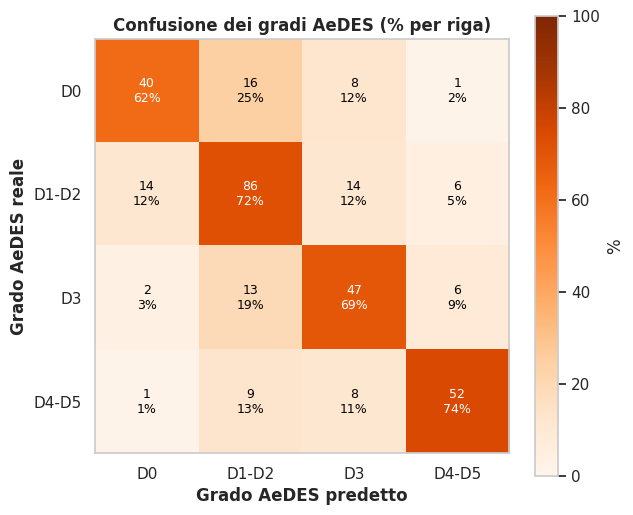

In [ ]:
# ============================================================================
# 6.5 · Matrice di confusione dei gradi AeDES: predizione vs ground truth
# ============================================================================

GRADI = ['D0','D1-D2','D3','D4-D5']
gidx = {g:i for i,g in enumerate(GRADI)}

def grado_base(g):  # rimuove "(traccia)" per la matrice
    return g.replace(' (traccia)','')

gp, gg = [], []
for m in sorted(f for f in os.listdir(PRED_DIR) if f.endswith('.png')):
    base = m[:-4]; gtp = os.path.join(GT_DIR, base+'_lab.png')
    if not os.path.exists(gtp): continue
    cp = conta_edifici(np.array(Image.open(os.path.join(PRED_DIR,m)).convert('RGB')))
    cg = conta_edifici(np.array(Image.open(gtp).convert('RGB')))
    if sum(cp.values())==0 or sum(cg.values())==0: continue
    gp.append(grado_base(grado_complessivo(cp)))
    gg.append(grado_base(grado_complessivo(cg)))

M = np.zeros((4,4), int)
for a,b in zip(gg,gp):
    if a in gidx and b in gidx: M[gidx[a], gidx[b]] += 1

acc = np.trace(M)/M.sum()*100 if M.sum() else 0
sotto = np.tril(M,-1).sum(); sopra = np.triu(M,1).sum()
print(f"Accuratezza classificazione AeDES: {acc:.1f}%  (n={M.sum()})")
print(f"Sottostime (grado reale > predetto): {sotto} ({sotto/M.sum()*100:.1f}%)  <-- falsi negativi agibilità")
print(f"Sovrastime (grado reale < predetto): {sopra} ({sopra/M.sum()*100:.1f}%)  (conservativo)\n")

Mn = M/M.sum(axis=1,keepdims=True).clip(min=1)*100
fig, ax = plt.subplots(figsize=(6.5,5.5))
im = ax.imshow(Mn, cmap='Oranges', vmin=0, vmax=100)
ax.set_xticks(range(4)); ax.set_xticklabels(GRADI); ax.set_yticks(range(4)); ax.set_yticklabels(GRADI)
ax.set_xlabel('Grado AeDES predetto', fontweight='bold'); ax.set_ylabel('Grado AeDES reale', fontweight='bold')
ax.set_title('Confusione dei gradi AeDES (% per riga)', fontweight='bold')
for i in range(4):
    for j in range(4):
        if M[i,j] > 0:
            ax.text(j,i,f"{M[i,j]}\n{Mn[i,j]:.0f}%", ha='center', va='center',
                    color='white' if Mn[i,j]>50 else 'black', fontsize=9)
ax.grid(False)
plt.colorbar(im, label='%'); plt.tight_layout(); plt.show()

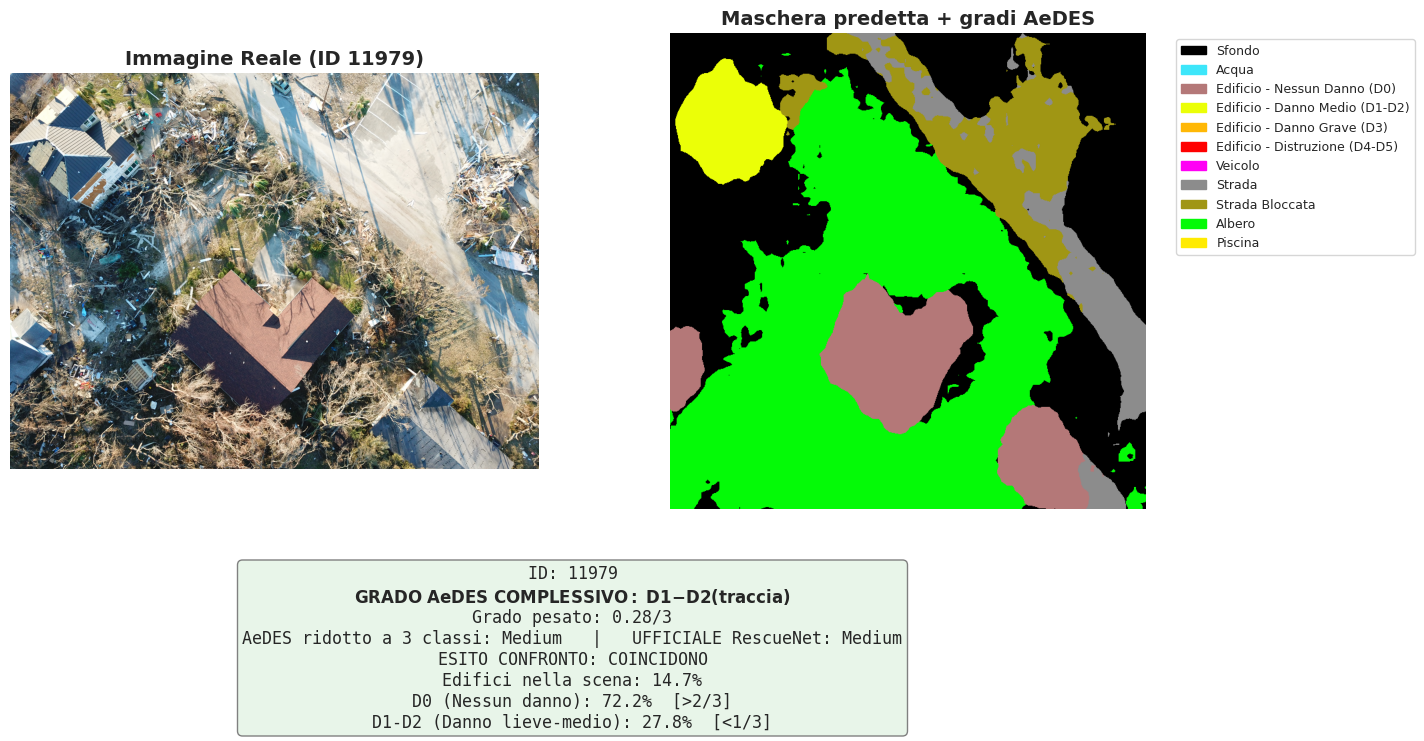

In [ ]:
# ============================================================================
# 6.6 · Interfaccia visiva finale con confronto
# ============================================================================

import random
import matplotlib.patches as mpatches

# ============================================================
MODALITA    = 'id'    # 'id' oppure 'random'
IMMAGINE_ID = '11979'     # es. '10794' se MODALITA='id'
SEED        = None        # numero per riproducibilità, None = casuale
# ============================================================

orig_dir = f'{DRIVE_BASE}/test_originali'
disp = sorted(f[:-4] for f in os.listdir(PRED_DIR) if f.endswith('.png'))

if MODALITA == 'random':
    if SEED is not None: random.seed(SEED)
    IMMAGINE_ID = random.choice(disp)
elif IMMAGINE_ID not in disp:
    raise SystemExit(f"ID '{IMMAGINE_ID}' non trovato. Esempi: {disp[:8]}")

def fascia_estensione(frazione):
    """Fasce di estensione standard AeDES."""
    if frazione == 0:      return '-'
    if frazione < 1/3:     return '<1/3'
    if frazione <= 2/3:    return '1/3-2/3'
    return '>2/3'

def apri(cartella, nome, exts):
    for e in exts:
        p = os.path.join(cartella, nome + e)
        if os.path.exists(p): return Image.open(p)
    return None

img_org  = apri(orig_dir, IMMAGINE_ID, ['.jpg','.JPG','.png'])
img_pred = apri(PRED_DIR, IMMAGINE_ID, ['.png'])
if img_pred is None:
    raise SystemExit("Maschera predetta non trovata.")

# --- calcolo AeDES per questa immagine ---
arr = np.array(img_pred.convert('RGB'))
c = conta_edifici(arr)
tot_ed = sum(c.values())

# --- grado ufficiale RescueNet dal CSV e riduzione AeDES a 3 classi ---
uff_idx  = GRADO_UFFICIALE.get(IMMAGINE_ID, None)        # 0/1/2 oppure None
uff_nome = RN_UFFICIALE[uff_idx] if uff_idx is not None else "non disponibile"

if tot_ed > 0:
    grado = grado_complessivo(c)
    pesato = grado_pesato(c)
    aedes_idx  = AEDES_TO_RN.get(grado_base(grado), None)     # AeDES ridotto a 0/1/2
    aedes_nome = RN_UFFICIALE[aedes_idx] if aedes_idx is not None else "n/d"

    # Rimosse le ripetizioni dei nomi delle classi, mantenuto solo il risultato e la direzione
    if uff_idx is None:
        esito = "NON DISPONIBILE"
    elif aedes_idx == uff_idx:
        esito = "COINCIDONO"
    else:
        verso = "Sottostima" if aedes_idx < uff_idx else "Sovrastima"
        esito = f"DIVERSI ({verso})"

    righe_txt = []
    for k in ORDINE:
        g, desc = MAP_AEDES[k]
        frac = c[k] / tot_ed * 100
        if frac > 0:
            righe_txt.append(f"{g} ({desc}): {frac:.1f}%  [{fascia_estensione(c[k]/tot_ed)}]")
    dettaglio = "\n".join(righe_txt)

    grado_grassetto = f"$\\mathbf{{GRADO\\ AeDES\\ COMPLESSIVO:\\ {grado.replace('-', '{-}')}}}$"

    info = (f"ID: {IMMAGINE_ID}\n"
            f"{grado_grassetto}\n"
            f"Grado pesato: {pesato:.2f}/3\n"
            f"AeDES ridotto a 3 classi: {aedes_nome}   |   UFFICIALE RescueNet: {uff_nome}\n"
            f"ESITO CONFRONTO: {esito}\n"
            f"Edifici nella scena: {tot_ed/(arr.shape[0]*arr.shape[1])*100:.1f}%\n"
            f"{dettaglio}")
else:
    info = (f"ID: {IMMAGINE_ID}\n"
            f"UFFICIALE RescueNet: {uff_nome}\n"
            f"Nessun edificio rilevato: grado AeDES non calcolabile.")

# --- palette RescueNet + voce dedicata al grado ufficiale nella legenda ---
COLORI_LEG = {
    (0,0,0):'Sfondo',(61,230,250):'Acqua',(180,120,120):'Edificio - Nessun Danno (D0)',
    (235,255,7):'Edificio - Danno Medio (D1-D2)',(255,184,6):'Edificio - Danno Grave (D3)',
    (255,0,0):'Edificio - Distruzione (D4-D5)',(255,0,245):'Veicolo',
    (140,140,140):'Strada',(160,150,20):'Strada Bloccata',(4,250,7):'Albero',(255,235,0):'Piscina'
}

fig, (a1, a2) = plt.subplots(1, 2, figsize=(15, 7))
if img_org is not None:
    a1.imshow(img_org)
a1.set_title(f"Immagine Reale (ID {IMMAGINE_ID})", fontsize=14, fontweight='bold')
a2.imshow(img_pred)
a2.set_title("Maschera predetta + gradi AeDES", fontsize=14, fontweight='bold')
a1.axis('off'); a2.axis('off')

# legenda colori delle classi
patches = [mpatches.Patch(color='#%02x%02x%02x' % rgb, label=l) for rgb, l in COLORI_LEG.items()]

leg = plt.legend(handles=patches, bbox_to_anchor=(1.05, 1), loc=2, fontsize=9)

# colore del box info secondo l'esito del confronto
if tot_ed > 0 and uff_idx is not None:
    facecolor = '#e8f5e9' if aedes_idx == uff_idx else '#ffebee'   # verde se coincide, rosso se no
else:
    facecolor = '#fff3e0'
fig.text(0.5, 0.12, info, ha='center', va='top', fontsize=12, family='monospace',
         bbox=dict(boxstyle='round', facecolor=facecolor, edgecolor='gray'))
plt.subplots_adjust(bottom=0.20)
plt.show()

/content/RescueNet-A-High-Resolution-Post-Disaster-UAV-Dataset-for-Semantic-Segmentation/Segmentation-Experiments
Checkpoint: train_epoch_100.pth  (100 epoche, regime res713)
Modello caricato in modalità inferenza.


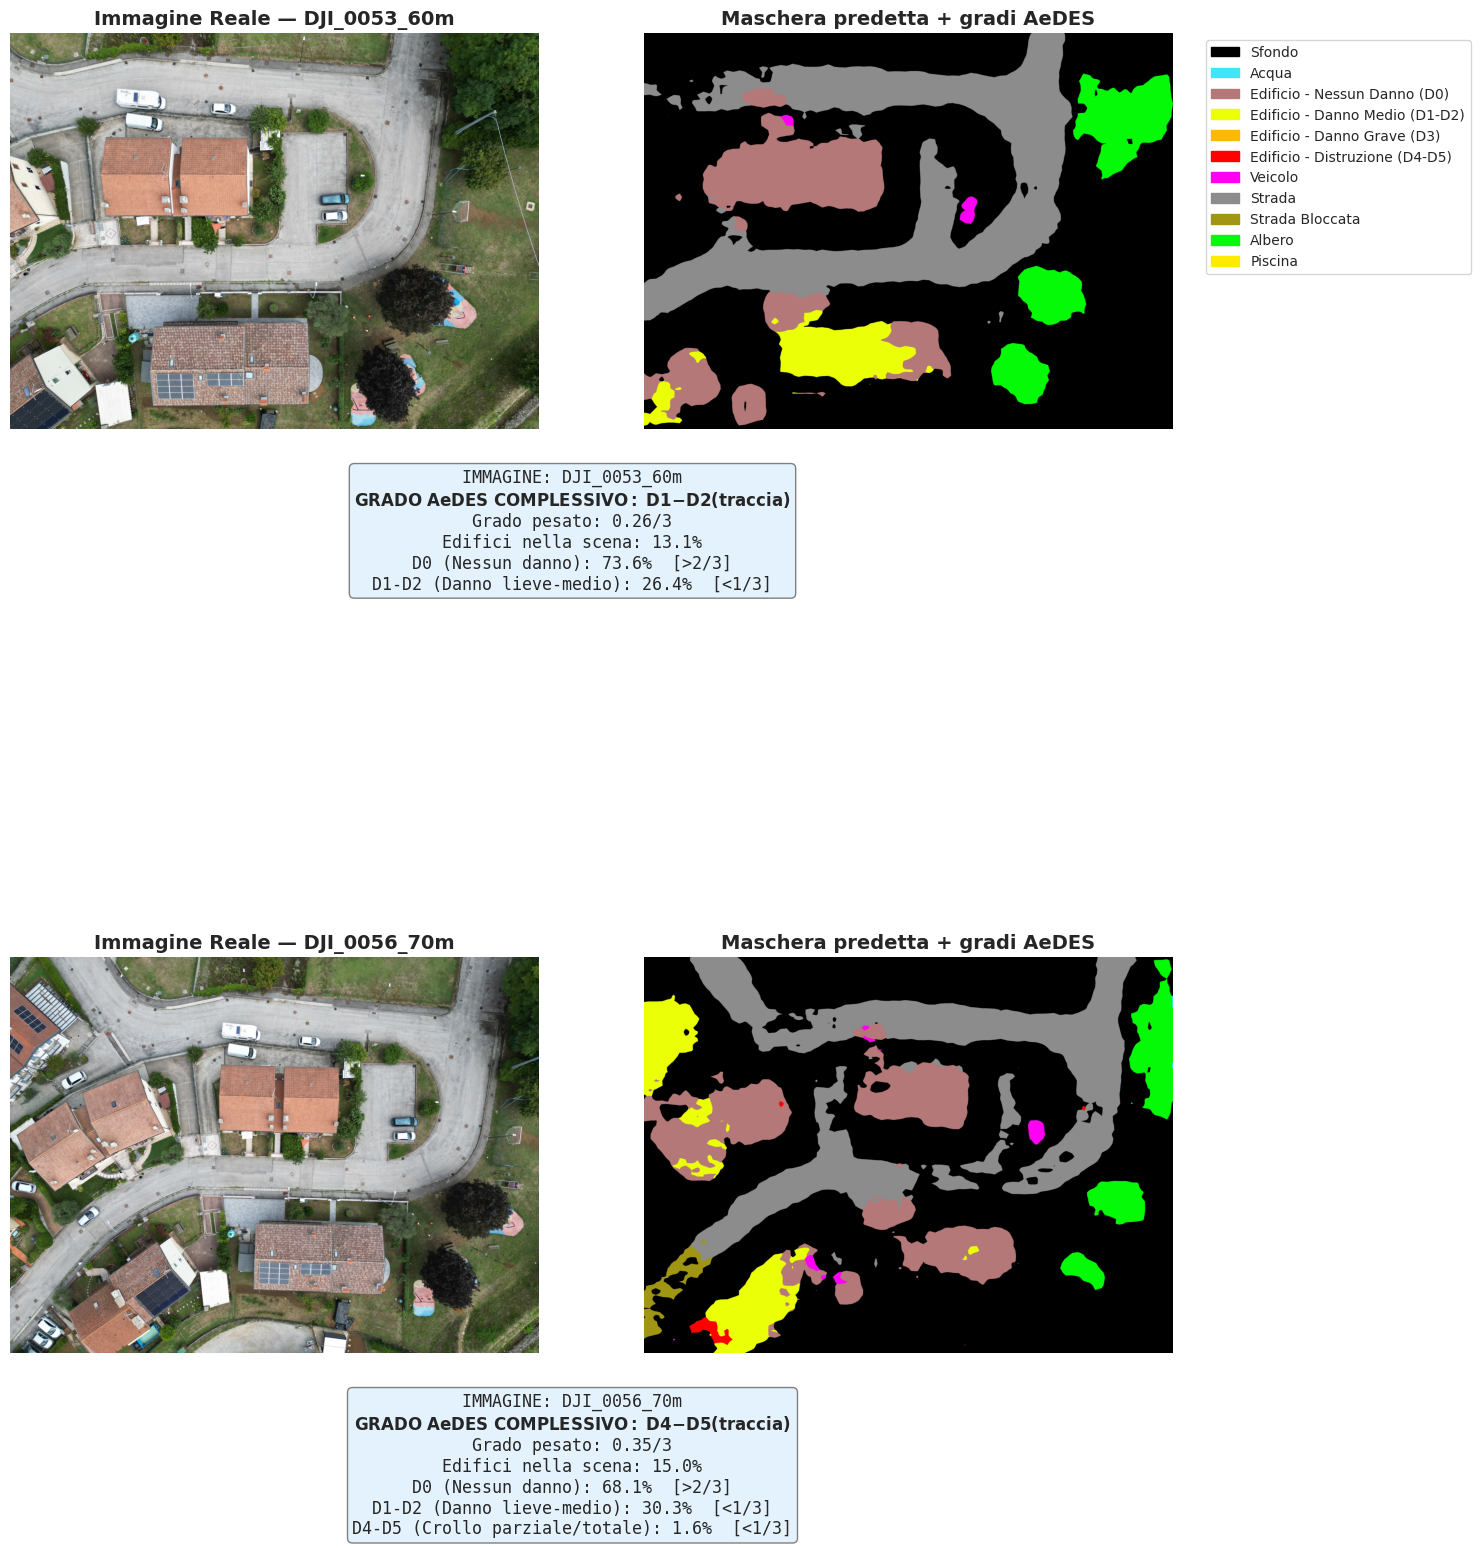

In [ ]:
# ============================================================================
# 6.7 · Interfaccia visiva analisi di due immagini custom
# ============================================================================

REPO = '/content/RescueNet-A-High-Resolution-Post-Disaster-UAV-Dataset-for-Semantic-Segmentation'
if not os.path.isdir(REPO):
    os.system('git clone -q https://github.com/BinaLab/RescueNet-A-High-Resolution-Post-Disaster-UAV-Dataset-for-Semantic-Segmentation.git')
%cd /content/RescueNet-A-High-Resolution-Post-Disaster-UAV-Dataset-for-Semantic-Segmentation/Segmentation-Experiments

import os
import numpy as np
import torch
import torch.nn.functional as F
from torchvision import transforms
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.transforms as mtransforms
from PIL import Image
from models.pspnet import PSPNet
import torchvision.transforms as transforms

# PATH DELLE IMMAGINI CHE VUOI ANALIZZARE
IMMAGINE_1 = '/content/drive/MyDrive/testdrone2/DJI_0053_60m.JPG'
IMMAGINE_2 = '/content/drive/MyDrive/testdrone2/DJI_0056_70m.JPG'

percorsi = [IMMAGINE_1, IMMAGINE_2]

# --- palette RescueNet ---
COLORI_LEG = {
    (0,0,0):'Sfondo',(61,230,250):'Acqua',(180,120,120):'Edificio - Nessun Danno (D0)',
    (235,255,7):'Edificio - Danno Medio (D1-D2)',(255,184,6):'Edificio - Danno Grave (D3)',
    (255,0,0):'Edificio - Distruzione (D4-D5)',(255,0,245):'Veicolo',
    (140,140,140):'Strada',(160,150,20):'Strada Bloccata',(4,250,7):'Albero',(255,235,0):'Piscina'
}

# --- Lista dei colori necessaria per la funzione colora() ---
LISTA_COLORI = list(COLORI_LEG.keys())

INPUT_SIZE = 713
MEAN, STD = [0.485,0.456,0.406], [0.229,0.224,0.225]
_norm = transforms.Normalize(MEAN, STD)

MODEL_DIR  = f'{DRIVE_BASE}/pspnet101_{REGIME}/model'

ck = glob.glob(f'{MODEL_DIR}/*.pth')
if not ck:
    raise SystemExit(f"Nessun checkpoint in {MODEL_DIR}")
CKPT = max(ck, key=lambda f: int(re.search(r'(\d+)\.pth$', f).group(1)))
EP = int(re.search(r'(\d+)\.pth$', CKPT).group(1))
print(f"Checkpoint: {os.path.basename(CKPT)}  ({EP} epoche, regime {REGIME})")

model = PSPNet(layers=101, classes=11, zoom_factor=8, pretrained=False)
model = torch.nn.DataParallel(model).cuda()
_ckpt = torch.load(CKPT, weights_only=False)
model.load_state_dict(_ckpt['state_dict'], strict=False)
model.eval()
print("Modello caricato in modalità inferenza.")

def predici(path, size=INPUT_SIZE):
    """Inferenza su una singola immagine -> mappa di indici di classe RescueNet."""
    img = Image.open(path).convert('RGB')
    w0, h0 = img.size
    t = transforms.ToTensor()(img.resize((size, size), Image.BILINEAR))
    t = _norm(t).unsqueeze(0).cuda()
    out = model(t)
    if isinstance(out, (tuple, list)): out = out[0]
    out = F.interpolate(out, size=(h0, w0), mode='bilinear', align_corners=True)
    return out.argmax(1)[0].cpu().numpy().astype(np.uint8)

def colora(idx, palette):
    rgb = np.zeros((*idx.shape, 3), np.uint8)
    for i, c in enumerate(palette):
        rgb[idx == i] = c
    return rgb

# Controllo sicurezza path
percorsi_validi = [p for p in percorsi if os.path.exists(p)]
if len(percorsi_validi) == 0:
    raise SystemExit("ATTENZIONE: Nessuna delle immagini inserite esiste. Controlla i percorsi!")

# Legenda
patches = [mpatches.Patch(color='#%02x%02x%02x' % c, label=n) for c, n in COLORI_LEG.items()]

# Configura la griglia
n = len(percorsi_validi)
fig, axes = plt.subplots(n, 2, figsize=(15, 10 * n))
if n == 1:
    axes = axes.reshape(1, 2)

for r, mia_immagine in enumerate(percorsi_validi):
    # 1. PREDIZIONE
    idx = predici(mia_immagine)
    rgb_pred = colora(idx, LISTA_COLORI)

    # Estrae l'ID dal nome per il report
    img_id = os.path.splitext(os.path.basename(mia_immagine))[0]

    # 2. CALCOLO AeDES (sulla matrice RGB appena predetta)
    c = conta_edifici(rgb_pred)
    tot_ed = sum(c.values())

    if tot_ed > 0:
        grado = grado_complessivo(c)
        pesato = grado_pesato(c)

        righe_txt = []
        for k in ORDINE:
            g, desc = MAP_AEDES[k]
            frac = c[k] / tot_ed * 100
            if frac > 0:
                righe_txt.append(f"{g} ({desc}): {frac:.1f}%  [{fascia_estensione(c[k]/tot_ed)}]")
        dettaglio = "\n".join(righe_txt)

        grado_grassetto = f"$\\mathbf{{GRADO\\ AeDES\\ COMPLESSIVO:\\ {grado.replace('-', '{-}')}}}$"
        info = (f"IMMAGINE: {img_id}\n"
                f"{grado_grassetto}\n"
                f"Grado pesato: {pesato:.2f}/3\n"
                f"Edifici nella scena: {tot_ed/(rgb_pred.shape[0]*rgb_pred.shape[1])*100:.1f}%\n"
                f"{dettaglio}")
    else:
        info = (f"IMMAGINE: {img_id}\n"
                f"Nessun edificio rilevato: grado AeDES non calcolabile.")

    # 3. VISUALIZZAZIONE
    a1, a2 = axes[r, 0], axes[r, 1]

    a1.imshow(Image.open(mia_immagine).convert('RGB'))
    a1.set_title(f"Immagine Reale — {img_id}", fontsize=14, fontweight='bold')
    a1.axis('off')

    a2.imshow(rgb_pred)
    a2.set_title("Maschera predetta + gradi AeDES", fontsize=14, fontweight='bold')
    a2.axis('off')

    center_transform = mtransforms.blended_transform_factory(fig.transFigure, a1.transAxes)

    a1.text(0.5, -0.1, info, transform=center_transform, ha='center', va='top',
            fontsize=12, family='monospace',
            bbox=dict(boxstyle='round', facecolor='#e3f2fd', edgecolor='gray'))

# Mostra la legenda in alto a destra
axes[0, 1].legend(handles=patches, bbox_to_anchor=(1.05, 1), loc=2, fontsize=10)

plt.subplots_adjust(hspace=0.5)
plt.show()

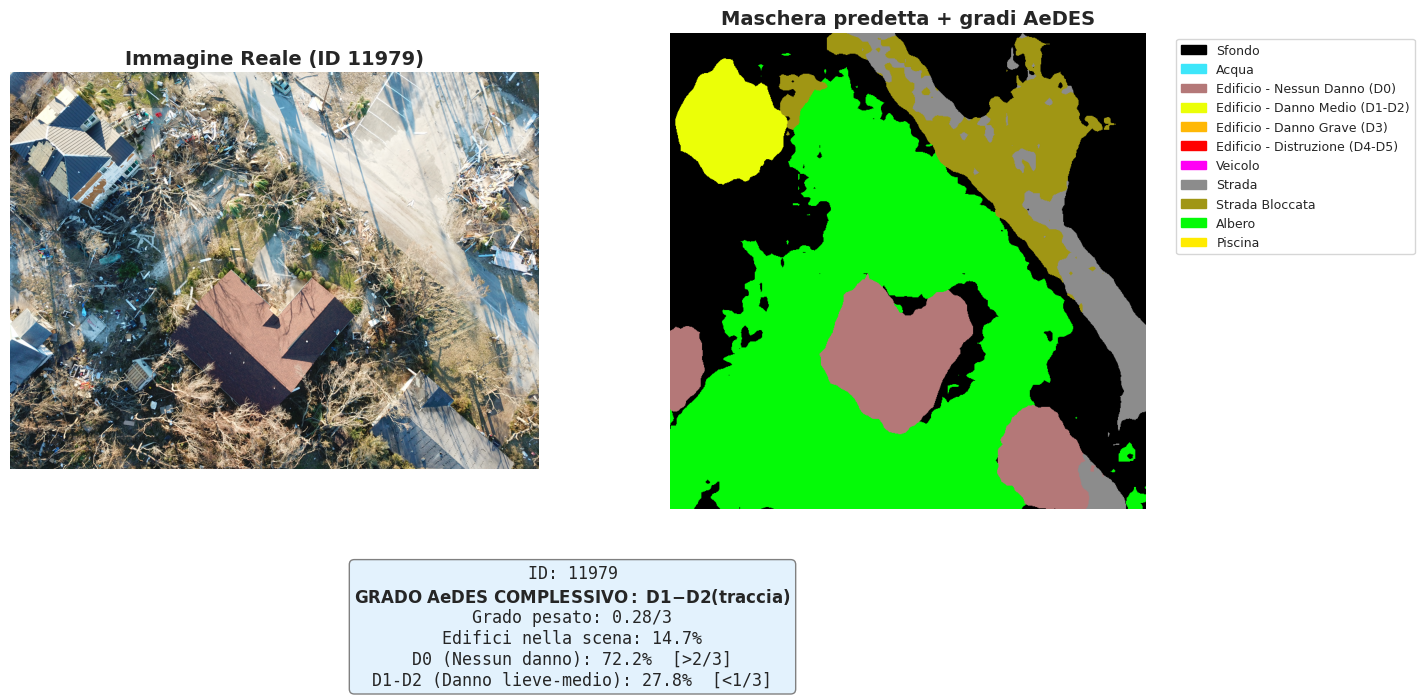

In [ ]:
# ============================================================================
# 6.8 · Interfaccia visiva finale
# ============================================================================

import random
import matplotlib.patches as mpatches

# ============================================================
MODALITA    = 'id'    # 'id' oppure 'random'
IMMAGINE_ID = '11979'     # es. '10794' se MODALITA='id'
SEED        = None        # numero per riproducibilità, None = casuale
# ============================================================

orig_dir = f'{DRIVE_BASE}/test_originali'
disp = sorted(f[:-4] for f in os.listdir(PRED_DIR) if f.endswith('.png'))

if MODALITA == 'random':
    if SEED is not None: random.seed(SEED)
    IMMAGINE_ID = random.choice(disp)
elif IMMAGINE_ID not in disp:
    raise SystemExit(f"ID '{IMMAGINE_ID}' non trovato. Esempi: {disp[:8]}")

def fascia_estensione(frazione):
    """Fasce di estensione standard AeDES."""
    if frazione == 0:      return '-'
    if frazione < 1/3:     return '<1/3'
    if frazione <= 2/3:    return '1/3-2/3'
    return '>2/3'

def apri(cartella, nome, exts):
    for e in exts:
        p = os.path.join(cartella, nome + e)
        if os.path.exists(p): return Image.open(p)
    return None

img_org  = apri(orig_dir, IMMAGINE_ID, ['.jpg','.JPG','.png'])
img_pred = apri(PRED_DIR, IMMAGINE_ID, ['.png'])
if img_pred is None:
    raise SystemExit("Maschera predetta non trovata.")

# --- calcolo AeDES per questa immagine ---
arr = np.array(img_pred.convert('RGB'))
c = conta_edifici(arr)
tot_ed = sum(c.values())

if tot_ed > 0:
    grado = grado_complessivo(c)
    pesato = grado_pesato(c)

    righe_txt = []
    for k in ORDINE:
        g, desc = MAP_AEDES[k]
        frac = c[k] / tot_ed * 100
        if frac > 0:
            righe_txt.append(f"{g} ({desc}): {frac:.1f}%  [{fascia_estensione(c[k]/tot_ed)}]")
    dettaglio = "\n".join(righe_txt)

    grado_grassetto = f"$\\mathbf{{GRADO\\ AeDES\\ COMPLESSIVO:\\ {grado.replace('-', '{-}')}}}$"
    info = (f"ID: {IMMAGINE_ID}\n"
            f"{grado_grassetto}\n"
            f"Grado pesato: {pesato:.2f}/3\n"
            f"Edifici nella scena: {tot_ed/(arr.shape[0]*arr.shape[1])*100:.1f}%\n"
            f"{dettaglio}")
else:
    info = (f"ID: {IMMAGINE_ID}\n"
            f"Nessun edificio rilevato: grado AeDES non calcolabile.")

# --- palette RescueNet ---
COLORI_LEG = {
    (0,0,0):'Sfondo',(61,230,250):'Acqua',(180,120,120):'Edificio - Nessun Danno (D0)',
    (235,255,7):'Edificio - Danno Medio (D1-D2)',(255,184,6):'Edificio - Danno Grave (D3)',
    (255,0,0):'Edificio - Distruzione (D4-D5)',(255,0,245):'Veicolo',
    (140,140,140):'Strada',(160,150,20):'Strada Bloccata',(4,250,7):'Albero',(255,235,0):'Piscina'
}

fig, (a1, a2) = plt.subplots(1, 2, figsize=(15, 7))
if img_org is not None:
    a1.imshow(img_org)
a1.set_title(f"Immagine Reale (ID {IMMAGINE_ID})", fontsize=14, fontweight='bold')
a2.imshow(img_pred)
a2.set_title("Maschera predetta + gradi AeDES", fontsize=14, fontweight='bold')
a1.axis('off'); a2.axis('off')

# legenda colori delle classi
patches = [mpatches.Patch(color='#%02x%02x%02x' % rgb, label=l) for rgb, l in COLORI_LEG.items()]
leg = plt.legend(handles=patches, bbox_to_anchor=(1.05, 1), loc=2, fontsize=9)

# text box
fig.text(0.5, 0.12, info, ha='center', va='top', fontsize=12, family='monospace',
         bbox=dict(boxstyle='round', facecolor='#e3f2fd', edgecolor='gray'))
plt.subplots_adjust(bottom=0.20)
plt.show()